(chap3_5)=

# 第 5 章 样条

本章讨论样条(spline)。它扩展了第 [3](chap2) 章介绍的概念,目的是为模型增加更大的灵活性。第
[3](chap2) 章中的模型假定因变量与自变量之间的关系在整个定义域上保持同一种形式。与此不同,
样条可以把一个问题拆成多个局部解,再把它们组合成一个有用的全局解。下面来看具体做法。

> **中文版现代化说明**:本章代码以 `notebooks_updated/chp_05.ipynb` 为起点,统一使用当前公开的
> PyMC、PyTensor、ArviZ、Patsy、NumPy 与 Matplotlib API。原笔记本中的 IPython magic 被移除,
> 使每个 Python 单元都可由标准解释器静态编译；数据与图片路径改为从本章目录出发的相对路径。
> `CH5_PROFILE=smoke|release` 只改变抽样预算与清单声明的图片 DPI,两种配置执行完全相同的模型与
> 绘图路径。默认是可复现、低预算的 `smoke`；发布结果应显式使用 `release`。
>
> 原代码用默认的非稳定快速排序按小时排序后每隔 50 行抽样；同一小时内的排序结果会随实现变化。
> 中文版把当前验证环境按该权威代码得到的 348 个原始 CSV 行号直接冻结,并在运行时核对行号、顺序、
> 数量和响应均值,使后续 pandas 排序实现变化不再悄悄更换分析样本。

In [1]:
import os
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt
from patsy import bs, dmatrix

from spline_helper import splines as plot_piecewise_splines

SEED = 435
PROFILE_NAME = os.getenv("CH5_PROFILE", "smoke").strip().lower()
PROFILES = {
    "smoke": {
        "draws": 20,
        "tune": 20,
        "compare_draws": 12,
        "compare_tune": 12,
        "chains": 1,
        "cores": 1,
        "figure_dpi": 100,
    },
    "release": {
        "draws": 1000,
        "tune": 1000,
        "compare_draws": 1000,
        "compare_tune": 1000,
        "chains": 4,
        "cores": min(4, os.cpu_count() or 1),
        "figure_dpi": 160,
    },
}
if PROFILE_NAME not in PROFILES:
    raise ValueError("CH5_PROFILE 必须是 'smoke' 或 'release'")
PROFILE = PROFILES[PROFILE_NAME]

SAMPLE_KWARGS = {
    "draws": PROFILE["draws"],
    "tune": PROFILE["tune"],
    "chains": PROFILE["chains"],
    "cores": PROFILE["cores"],
    "random_seed": SEED,
    "target_accept": 0.9,
    "blas_cores": 1,
    "progressbar": False,
    "compute_convergence_checks": True,
}
COMPARE_SAMPLE_KWARGS = {
    **SAMPLE_KWARGS,
    "draws": PROFILE["compare_draws"],
    "tune": PROFILE["compare_tune"],
}

DATA_DIR = Path("data")
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

az.style.use("arviz-grayscale")
plt.rcParams["figure.dpi"] = PROFILE["figure_dpi"]
assert plt.rcParams["figure.dpi"] == PROFILE["figure_dpi"]
rng = np.random.default_rng(SEED)

# 固定顺序的 8 色无障碍分类色板；本章最多同时使用前 7 个槽位。
SERIES_COLORS = (
    "#2a78d6", "#eb6834", "#1baf7a", "#eda100",
    "#e87ba4", "#008300", "#4a3aa7", "#e34948",
)

(polynomial-regression)=

## 多项式回归

正如第 [3](chap2) 章已经看到的,线性模型可以写成:

```{math}
:label: eq:lin_model
\mathbb{E}[Y]= \beta_0 + \beta_1 X
```

其中,$\beta_0$ 是截距,$\beta_1$ 是斜率,$\mathbb{E}[Y]$ 是响应随机变量 $Y$ 的期望值,也就是
均值。式 {eq}`eq:lin_model` 可以改写为:

```{math}
:label: eq:polynomial_reg
\mathbb{E}[Y]= \beta_0 + \beta_1 X + \beta_2 X^2 + \cdots + \beta_m X^m
```

这称为**多项式回归(polynomial regression)**。乍看之下,式 {eq}`eq:polynomial_reg` 似乎表示
以 $X,X^2,\cdots,X^m$ 为协变量的多元线性回归。这种理解在某种意义上没有错,但必须注意:
所有协变量 $X^m$ 都来自同一个 $X$,只是依次取了从 1 到 $m$ 次幂。因此就实际问题而言,我们仍然
只拟合了一个预测变量。

$m$ 称为多项式的次数(degree)。第 [3](chap2) 章和第 [4](chap3) 章的线性回归模型都是 1 次
多项式,唯一的例外是 {ref}`transforming_covariates` 节中方差随协变量变化的例子,那里使用了
$m=1/2$。

{numref}`fig:polynomial_regression` 给出了次数为 2、10 和 15 的 3 个多项式回归例子。随着次数
增加,曲线会变得更灵活。

In [2]:
x_poly = rng.normal(0.5, 1.0, 50)
y_poly = rng.normal(x_poly**2, 1.0)
x_poly_grid = np.linspace(x_poly.min(), x_poly.max(), 500)

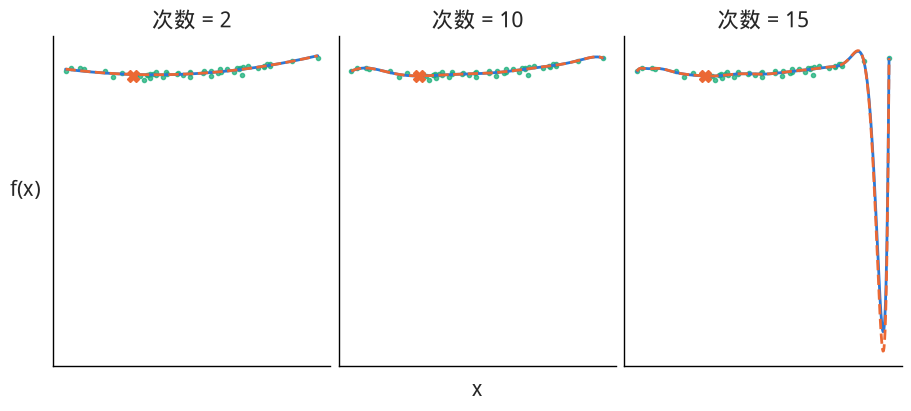

In [3]:
figure, axes = plt.subplots(1, 3, figsize=(9, 4), sharex=True, sharey=True)
removed_index = len(x_poly) - 1
kept = np.arange(len(x_poly)) != removed_index

for degree, axis in zip((2, 10, 15), axes, strict=True):
    axis.plot(x_poly, y_poly, ".", color=SERIES_COLORS[2], alpha=0.75, label="全部观测")
    full_fit = np.poly1d(np.polyfit(x_poly, y_poly, deg=degree))
    axis.plot(x_poly_grid, full_fit(x_poly_grid), color=SERIES_COLORS[0], linewidth=2)

    reduced_fit = np.poly1d(np.polyfit(x_poly[kept], y_poly[kept], deg=degree))
    axis.plot(
        x_poly_grid,
        reduced_fit(x_poly_grid),
        color=SERIES_COLORS[1],
        linewidth=2,
        linestyle="--",
    )
    axis.plot(
        x_poly[removed_index],
        y_poly[removed_index],
        marker="X",
        color=SERIES_COLORS[1],
        markersize=8,
    )
    axis.set_title(f"次数 = {degree}")
    axis.set_xticks([])
    axis.set_yticks([])

axes[1].set_xlabel("x", labelpad=10)
axes[0].set_ylabel("f(x)", rotation=0, labelpad=20)
figure.savefig(FIGURE_DIR / "polynomial_regression.png", bbox_inches="tight")

> **中文版现代化说明**:原更新版代码删除的是最后一个观测,却把第一个观测画成叉号。这里让虚线拟合
> 与叉号指向同一个被删除观测,从而与图注的语义一致。

```{figure} figures/polynomial_regression.png
:name: fig:polynomial_regression
:width: 8.00in
次数为 2、10 和 15 的多项式回归示例。次数越高,拟合越*曲折(wiggly)*。蓝色实线使用全部
观测,橙色虚线表示删除橙色叉号所标观测后的拟合。删除一个数据点对 2 次和 10 次多项式的影响较小,
但对 15 次多项式的影响较大。
拟合使用最小二乘法计算。
```

多项式的一个问题是它会产生*全局*作用。使用 $m$ 次多项式,等于声称自变量与因变量之间在整个
数据集上的关系都是 $m$ 次的。当数据的不同区域需要不同程度的灵活性时,这会造成问题,例如得到
*过于灵活*的曲线 [^1]。在 {numref}`fig:polynomial_regression` 的最后一个面板(次数为 15)中,
即使高 $X$ 区域没有取值如此低或如此高的数据点,拟合曲线仍出现了一个*深谷*,紧接着又出现一个
*高峰*。

此外,随着次数增加,拟合对删除数据点会越来越敏感；等价地说,它也会对未来新增的数据越来越敏感。
换言之,次数越高,模型越容易过拟合。例如在 {numref}`fig:polynomial_regression` 中,实线表示
对全部数据的拟合,虚线表示删去图中叉号标出的一个数据点后的拟合。尤其在最后一个面板中,仅删除
一个点就会改变模型拟合,而且影响会扩散到远离该点的位置。

(expanding_feature_space)=

## 扩展特征空间

从概念上看,可以把多项式回归理解为一种创建新预测变量的配方；更正式地说,它是在**扩展特征空间
(expanding the feature space)**。完成扩展后,我们可以在扩展空间里拟合一条直线,而这条直线
映射回原始数据空间时会成为一条曲线,非常巧妙!不过,特征扩展并不是统计无政府主义的邀请。我们
不能随意对数据施加随机变换,然后期待总能得到好结果。事实上,刚才已经看到,多项式并非没有问题。

把特征扩展的思想推广到多项式之外,可以把式 {eq}`eq:lin_model` 展开为:

```{math}
:label: eq:bfr
\mathbb{E}[Y]= \beta_0 + \beta_1 B_{1}(X_{1}) + \beta_2 B_{2}(X_{2}) + \cdots + \beta_m B_{m}(X_{m})
```

其中 $B_i$ 是任意函数。在这个语境中,这些函数称为**基函数(basis function)**。它们的线性组合
给出函数 $f$,也就是我们实际“看到”的模型对数据的拟合。从这个意义上说,$B_i$ 是在幕后构造
灵活函数 $f$ 的技巧。

```{math}
:label: eq:bfr2
\mathbb{E}[Y]= \sum_i^m \beta_i B_{i}(X_{i}) = f(X)
```

$B_i$ 基函数有许多选择。可以使用多项式,从而得到刚才讨论的多项式回归；也可以任意组合平方、
对数或平方根等函数。这些函数可以由具体问题所启发。例如在 {ref}`transforming_covariates` 节中,
我们通过开平方来建模婴儿身长如何随年龄变化。这一选择受到如下事实启发:人类婴儿和其他哺乳动物
一样,生命早期生长更快,之后增速趋于平缓,这与平方根函数的形状相似。

另一种选择是使用 $I(c_i \leq x_k < c_j)$ 这样的指示函数,把原始预测变量
$\boldsymbol{X}$ 拆成互不重叠的子集,再只在各子集内部*局部*拟合多项式。这个过程会得到
**分段多项式(piecewise polynomial)** [^2],如 {numref}`fig:piecewise` 所示。

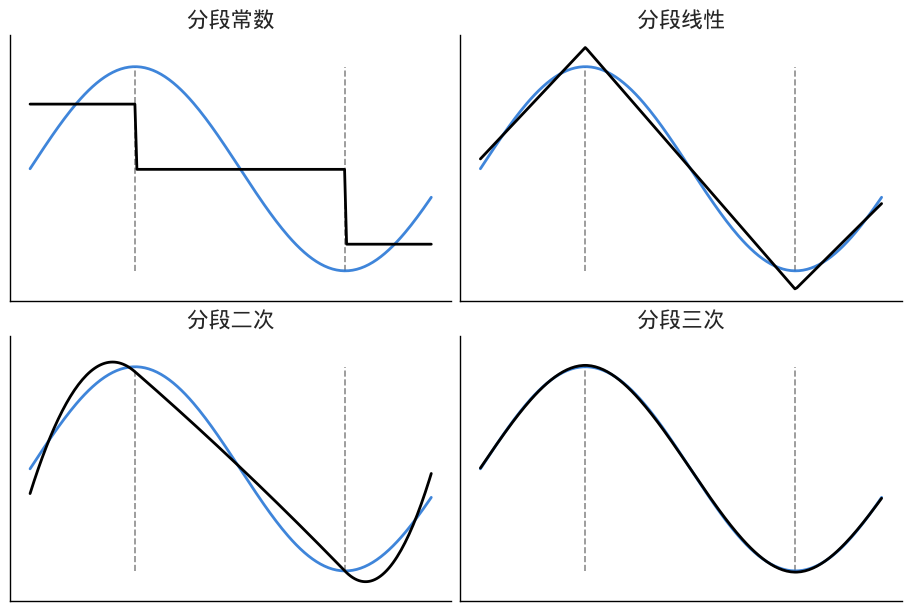

In [4]:
piecewise_figure, _ = plot_piecewise_splines([1.57, 4.71])
piecewise_figure.savefig(FIGURE_DIR / "piecewise.png", bbox_inches="tight")

```{figure} figures/piecewise.png
:name: fig:piecewise
:width: 8.00in
蓝线是我们希望逼近的*真实*函数。黑色实线是次数依次增加的分段多项式(0、1、2 和 3),分别
对应分段常数、分段线性、分段二次和分段三次拟合。灰色竖虚线标出 x 轴上各子定义域的边界。
```

{numref}`fig:piecewise` 的 4 个面板有同一个目标:逼近蓝色函数。首先用灰色虚线把函数拆成 3 个
子定义域,然后在每个子定义域上拟合不同的函数。第一个子图使用分段常数,也就是拟合常数函数。
常数函数可以看作 0 次多项式。由 3 条黑色线段组成的汇总解称为**阶梯函数(step function)**。
这种近似看起来相当粗糙,但可能已经足够。例如,如果我们想研究早晨、下午和夜间的期望平均温度
这类不连续结果,阶梯函数可能很合适；又或者,即使认为结果本身是平滑的,我们也能接受一个不平滑
的近似 [^3]。

第二个面板使用分段线性,做法与第一个面板相同,但把常数函数换成一次多项式,也就是线性函数。
注意相邻线性解会在虚线处相接,这是有意施加的约束。我们可以把它解释为:希望最终解尽可能平滑
[^4]。

第三个面板使用分段二次多项式,第四个面板使用分段三次多项式。随着分段多项式次数提高,解会越来越
灵活,拟合可能更好,但过拟合的风险也更高。

因为最终拟合函数 $f$ 由局部解(即 $B_i$ 基函数)构成,我们更容易让模型在不同区域使用符合数据
需求的灵活度。在这个例子中,可以在不同区域使用更简单的函数(次数更低的多项式),同时仍在整个
数据定义域上获得良好的总体拟合。

目前一直假定只有一个预测变量 $X$,但同一思想也可以推广到多个预测变量
$X_0,X_1,\cdots,X_p$,甚至可以再加入逆链接函数 $\phi$ [^5]。这种形式的模型称为**广义加性模型
(Generalized Additive Model, GAM)** {cite:p}`GelmanBayesianDataAnalysis2013, WoodGeneralizedAdditiveModels2017`:

```{math}
:label: eq:GAM
\mathbb{E}[Y]= \phi \left(\sum_i^p f(X_i)\right)
```

总结本节,式 {eq}`eq:bfr` 中的 $B_i$ 函数是一种巧妙的统计装置,让我们能够拟合更灵活的模型。
原则上可以自由选择任意 $B_i$:依据领域知识、探索性数据分析结果,甚至反复试验来选择。不过,不同
变换具有不同的统计性质,因此如果能有一组在广泛数据集上都表现良好的*默认*函数会很方便。从下一节
开始直到本章结束,讨论将限制在一类称为 B 样条(B-spline) [^6] 的基函数上。

(introducing-splines)=

## 样条简介

样条可以看成这样一种尝试:保留多项式的灵活性,同时把这种灵活性控制住,从而得到整体统计性质
良好的模型。定义样条时需要给出**节点(knot)** [^7]。节点的作用是把变量 $\boldsymbol{X}$ 的
定义域拆成一系列相邻区间。例如,{numref}`fig:piecewise` 中灰色竖虚线所表示的就是节点。对本章
而言,样条是受到连续性约束的分段多项式,也就是强制两个相邻子多项式在节点处相接。如果子多项式
次数为 $n$,就称该样条为 $n$ 次样条。有时也按阶数(order)称呼样条,此时阶数为 $n+1$。

从 {numref}`fig:piecewise` 可以看到,随着分段多项式次数增加,结果函数的*平滑度*也会提高。前面
已经提到,子多项式应当在节点处相接。第一个面板似乎有点“作弊”,因为每条线之间存在跳跃,也就是
不连续；但如果每个区间只能使用常数,这已经是能够做到的最好结果。

讨论样条时,这些子多项式正式称为**基样条(basis spline)**,简称 B 样条。给定次数的任意样条函数,
都可以由同次数 B 样条的线性组合构成。{numref}`fig:splines_basis` 给出了次数从 0 到 3(从上到下)
的 B 样条例子。底部圆点表示节点,蓝点标出了加粗黑色 B 样条不为零的区间。为清晰起见,其他
B 样条都画成较细的虚线,但所有 B 样条同等重要。事实上,{numref}`fig:splines_basis` 的每个子图
都展示了由给定节点所定义的全部 B 样条。换言之,一组节点和一个次数就能完全确定 B 样条。

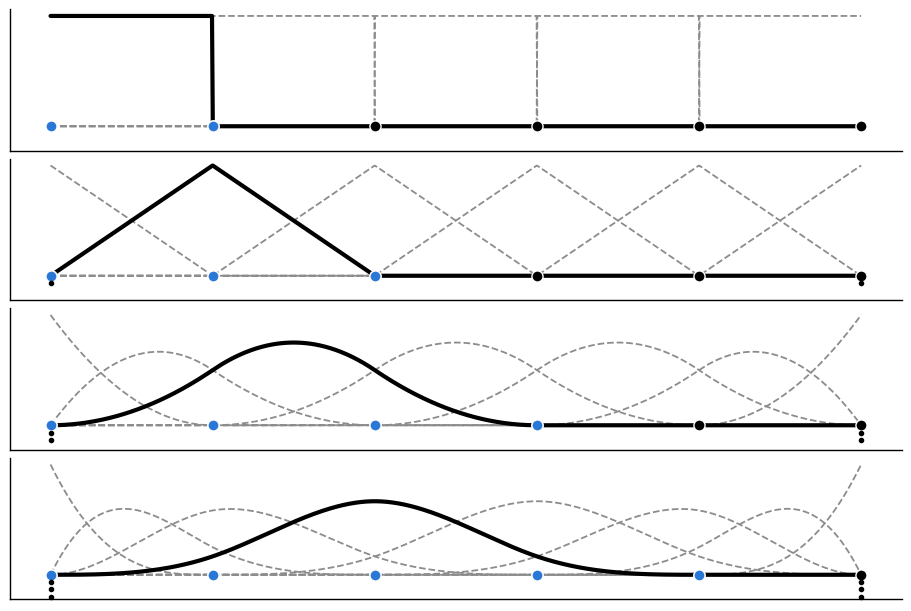

In [5]:
x_basis = np.linspace(0.0, 1.0, 1000)
basis_knots = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
interior_basis_knots = basis_knots[1:-1]

figure, axes = plt.subplots(4, 1, figsize=(9, 6), sharex=True, sharey=True)
for degree, axis in enumerate(axes):
    basis_matrix = np.asarray(
        bs(
            x_basis,
            degree=degree,
            knots=interior_basis_knots,
            lower_bound=basis_knots[0],
            upper_bound=basis_knots[-1],
            include_intercept=True,
        )
    )
    assert np.allclose(basis_matrix.sum(axis=1), 1.0)
    assert np.all(basis_matrix.max(axis=0) > 0)
    for column in basis_matrix.T:
        axis.plot(x_basis, column, color="0.55", linewidth=1.3, linestyle="--")
    highlighted = min(degree, basis_matrix.shape[1] - 1)
    axis.plot(x_basis, basis_matrix[:, highlighted], color="black", linewidth=3)
    axis.plot(basis_knots, np.zeros_like(basis_knots), "ko", markeredgecolor="white", markersize=8)
    axis.plot(
        basis_knots[: degree + 2],
        np.zeros(degree + 2),
        "o",
        color=SERIES_COLORS[0],
        markeredgecolor="white",
        markersize=8,
    )
    for padding_index in range(1, degree + 1):
        axis.plot([0, 1], [-padding_index / 15] * 2, "k.", clip_on=False)

axes[-1].set_ylim(bottom=-0.22)
axes[-1].set_xticks([])
for axis in axes:
    axis.set_yticks([])
figure.savefig(FIGURE_DIR / "splines_basis.png", bbox_inches="tight")

> **中文版现代化说明**:Patsy 的 `knots=` 参数表示内部节点,边界应通过 `lower_bound` 与
> `upper_bound` 单独指定。原更新版把 0 和 1 同时当成内部节点,会在当前 Patsy 中产生无支撑的
> 全零基函数列。这里把 0 与 1 作为边界,只把 0.2、0.4、0.6、0.8 传给 `knots=`,并断言基函数
> 构成单位分解且没有全零列。

```{figure} figures/splines_basis.png
:name: fig:splines_basis
:width: 8.00in
次数从 0 到 3 的 B 样条。最上方子图是阶梯函数,第二幅是三角函数,再往下则越来越接近高斯形状。
边界处*堆叠*的节点(较小黑点)用于定义靠近边界的样条。
```

从 {numref}`fig:splines_basis` 可以看到,随着 B 样条次数提高,单个 B 样条覆盖的定义域会越来越宽
[^8]。因此,要让高次样条有意义,需要定义更多节点。还要注意,每个 B 样条只在某个给定区间内
非零。正是这一性质,使样条回归比多项式回归更具有*局部性*。

随着次数增加,控制每个 B 样条所需的节点数也会增加。因此对所有大于 0 的次数,边界附近一开始
无法定义完整的 B 样条。这也解释了为什么在 {numref}`fig:splines_basis` 中,随着次数提高,黑色
高亮 B 样条逐渐向右移动。边界处 B 样条更少会让近似质量受损。幸运的是,解决办法很简单:在边界
补充节点,也就是图中的小圆点。

假设节点为 $(0,1,2,3,4,5)$,并希望拟合三次样条,实际要使用
$(0,0,0,0,1,2,3,4,5,5,5,5)$。也就是说,开头把 0 再补 3 次,结尾把 5 再补 3 次。这样就有
$(0,0,0,0,1)$ 这 5 个节点来定义第一个 B 样条,也就是
{numref}`fig:splines_basis` 最后一个面板里形似指数分布的靛蓝虚线。随后用 $(0,0,0,1,2)$ 定义
第二个 B 样条,它看起来像 Beta 分布,依此类推。第一个*完整* B 样条(黑色高亮)由蓝色节点
$(0,1,2,3,4)$ 定义。边界补点次数与样条次数相同,所以 0 次样条无需额外节点,3 次样条则需要
额外补 6 个节点。

单个 B 样条本身用处有限,但所有 B 样条的线性组合可以拟合复杂函数。因此在实践中,拟合样条需要
选择 B 样条的阶数、节点数量和位置,再求出一组系数来加权每个 B 样条。
{numref}`fig:splines_weighted` 展示了这个过程。第一行用不同颜色区分各个基函数,每个子图底部的
黑点表示节点。第二行更关键:它把第一行同样的基函数按一组 $\beta_i$ 系数缩放。较粗的黑色实线是
这些加权 B 样条之和,也就是最终样条。

下面先用 Patsy 构建设计矩阵。次数 0 对应分段常数,次数 1 对应分段线性,次数 3 对应三次样条。

In [6]:
x_dense = np.linspace(0.0, 1.0, 500)
knots = [0.25, 0.5, 0.75]

B0_dense = np.asarray(
    dmatrix(
        "bs(x, knots=knots, degree=0, include_intercept=True) - 1",
        {"x": x_dense, "knots": knots},
    )
)
B1_dense = np.asarray(
    dmatrix(
        "bs(x, knots=knots, degree=1, include_intercept=True) - 1",
        {"x": x_dense, "knots": knots},
    )
)
B3_dense = np.asarray(
    dmatrix(
        "bs(x, knots=knots, degree=3, include_intercept=True) - 1",
        {"x": x_dense, "knots": knots},
    )
)

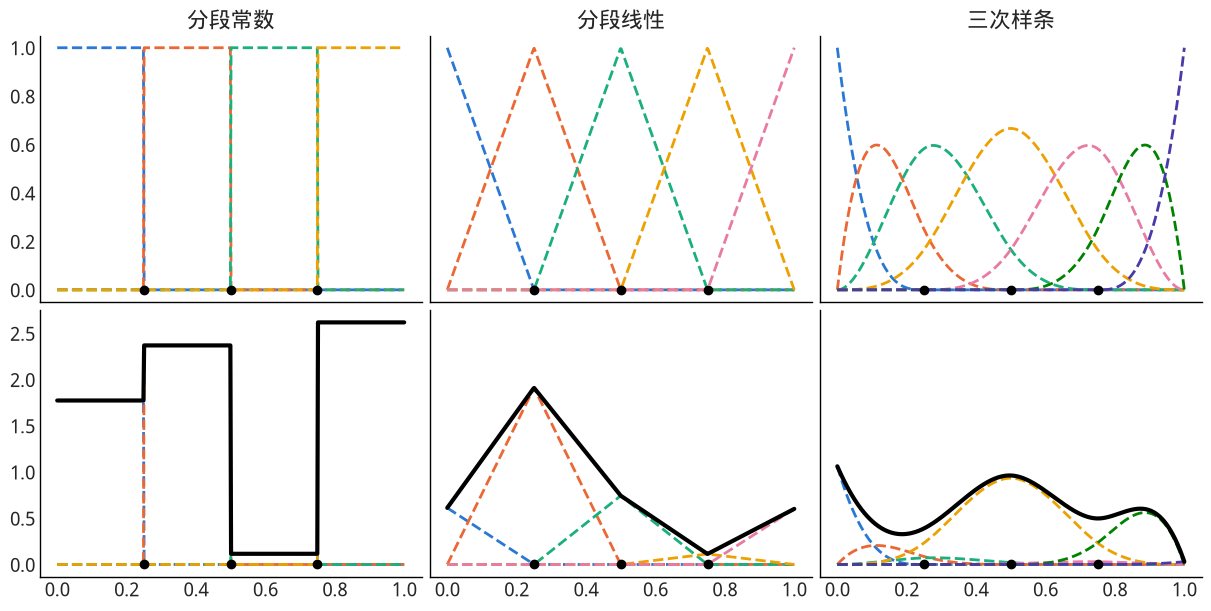

In [7]:
weighted_rng = np.random.default_rng(1563)
figure, axes = plt.subplots(2, 3, figsize=(12, 6), sharex=True, sharey="row")
titles = ("分段常数", "分段线性", "三次样条")

for panel, (matrix, title) in enumerate(zip((B0_dense, B1_dense, B3_dense), titles, strict=True)):
    colors = SERIES_COLORS[: matrix.shape[1]]
    for column_index, color in enumerate(colors):
        axes[0, panel].plot(
            x_dense,
            matrix[:, column_index],
            color=color,
            linewidth=2,
            linestyle="--",
        )

    coefficients = np.abs(weighted_rng.normal(0, 1, size=matrix.shape[1]))
    for column_index, color in enumerate(colors):
        axes[1, panel].plot(
            x_dense,
            matrix[:, column_index] * coefficients[column_index],
            color=color,
            linewidth=2,
            linestyle="--",
        )

    axes[1, panel].plot(x_dense, matrix @ coefficients, color="black", linewidth=3)
    axes[0, panel].plot(knots, np.zeros_like(knots), "ko", markersize=6)
    axes[1, panel].plot(knots, np.zeros_like(knots), "ko", markersize=6)
    axes[0, panel].set_title(title)

figure.savefig(FIGURE_DIR / "splines_weighted.png", bbox_inches="tight")

```{figure} figures/splines_weighted.png
:name: fig:splines_weighted
:width: 8.00in
用 Patsy 定义的 B 样条。第一行从左到右分别是阶数为 1(分段常数)、2(分段线性)和 4(三次)的
样条；每个基函数以不同颜色的虚线表示。第二行把第一行的基样条按一组系数缩放。
粗黑线表示这些基函数之和。因为系数是随机选取的,第二行每个子图都可以看成从*样条空间*上的先验
分布抽取的一个随机样本。
```

本例中的 $\beta_i$ 系数来自半正态分布,对应代码块
[splines_patsy_plot](splines_patsy_plot) 中生成正系数的步骤。因此,
{numref}`fig:splines_weighted` 的每个面板只展示了样条概率分布的一次实现。删除随机种子并多次运行
该代码块,每次都会看到不同的样条。还可以把半正态分布替换为正态分布、指数分布等。
{numref}`fig:splines_realizations` 展示了三次样条的 4 次实现。

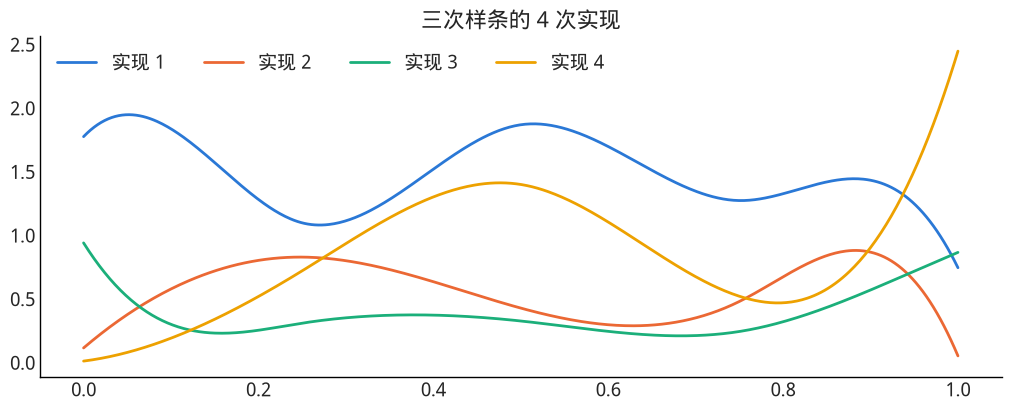

In [8]:
realization_rng = np.random.default_rng(1563)
figure, axis = plt.subplots(figsize=(10, 4))
for realization, color in zip(range(4), SERIES_COLORS[:4], strict=True):
    coefficients = np.abs(realization_rng.normal(0, 1, size=B3_dense.shape[1]))
    axis.plot(
        x_dense,
        B3_dense @ coefficients,
        color=color,
        linewidth=2,
        label=f"实现 {realization + 1}",
    )
axis.set_title("三次样条的 4 次实现")
axis.legend(ncol=4, frameon=False)
figure.savefig(FIGURE_DIR / "splines_realizations.png", bbox_inches="tight")

```{figure} figures/splines_realizations.png
:name: fig:splines_realizations
:width: 8.00in
$\beta_i$ 系数从半正态分布抽取时,三次样条的 4 次实现。
```

::: {admonition} 对样条而言,四阶已经显得拥挤

在所有可能的样条中,三次样条或许最常用。但三次样条为什么堪称样条中的“女王”?
{numref}`fig:piecewise` 和 {numref}`fig:splines_weighted` 提供了一些线索。对大多数常见场景而言,
三次样条是能够生成“足够平滑”曲线的最低次数样条,因此更高次样条通常没有那么有吸引力。

“足够平滑”是什么意思?不深入数学细节地说,拟合函数不应突然改变斜率。一种实现方式是要求相邻
分段多项式在共同节点处相接。三次样条还有另外两个约束:一阶和二阶导数也连续,也就是说节点处的
斜率连续,而且“斜率的斜率”也连续 [^9]。事实上,$m$ 次样条在节点处会有 $m-1$ 阶连续导数。
尽管如此,更低次或更高次的样条在某些问题中仍然有用；只是三次样条是很好的默认选择。
:::

(building-the-design-matrix-using-patsy)=

## 使用 Patsy 构建设计矩阵

在 {numref}`fig:splines_basis` 和 {numref}`fig:splines_weighted` 中已经画出了 B 样条,但还没有
说明如何计算它们。主要原因是手工计算相当繁琐,而 SciPy 等软件包已经提供了高效算法 [^10]。
因此,本章不会从头推导 B 样条的计算过程,而是使用 Patsy。Patsy 是一个描述统计模型并构建设计
矩阵(design matrix)的软件包,特别适合线性模型或包含线性部分的模型。它深受 R 语言生态中广泛
使用的*公式迷你语言(formula mini-language)*启发。简单体验一下:带两个协变量的线性模型可以写成
`"y ~ x1 + x2"`,若要加入交互项则可以写成 `"y ~ x1 + x2 + x1:x2"`。这与第 [3](chap2) 章
介绍 Bambi 的边注中所示语法相似。更多细节见 Patsy 文档 [^11]。

要在 Patsy 中定义 B 样条设计矩阵,需要向 `dmatrix` 传入一个以 `bs()` 这个*片段*开头的字符串。
虽然它写在字符串中,Patsy 会把它解析为函数,因此可以接收多个参数,包括数据、给出节点位置的
类数组对象以及样条次数。下面的代码块 [splines_patsy](splines_patsy) 定义 3 个设计矩阵:次数
分别为 0(分段常数)、1(分段线性)和 3(三次样条)。

(splines_patsy)=
**代码块 `splines_patsy`** 已在上面的 `ch05-patsy-design-matrices-dense` 单元中给出；其变量
`B0_dense`、`B1_dense` 和 `B3_dense` 分别对应原书的 `B0`、`B1` 和 `B3`。

{numref}`fig:design_matrices` 展示了代码块 [splines_patsy](splines_patsy) 计算出的 3 个设计矩阵。
为了更好地理解 Patsy 的工作方式,建议在 Jupyter Notebook/Lab 或常用 IDE 中直接检查 `B0`、
`B1` 和 `B3` 对象。

> **中文版现代化说明**:英文正文这里写成 `B0`、`B1`、`B2`,但相邻代码实际定义的是 `B0`、
> `B1`、`B3`,分别表示 0、1、3 次样条。中文版按可执行对象更正为 `B3`,并在元数据中保留原始
> 行号以便追溯。

In [9]:
x_small = np.linspace(0.0, 1.0, 20)
small_context = {"x": x_small, "knots": knots}
B0 = np.asarray(
    dmatrix(
        "bs(x, knots=knots, degree=0, include_intercept=True) - 1",
        small_context,
    )
)
B1 = np.asarray(
    dmatrix(
        "bs(x, knots=knots, degree=1, include_intercept=True) - 1",
        small_context,
    )
)
B3 = np.asarray(
    dmatrix(
        "bs(x, knots=knots, degree=3, include_intercept=True) - 1",
        small_context,
    )
)

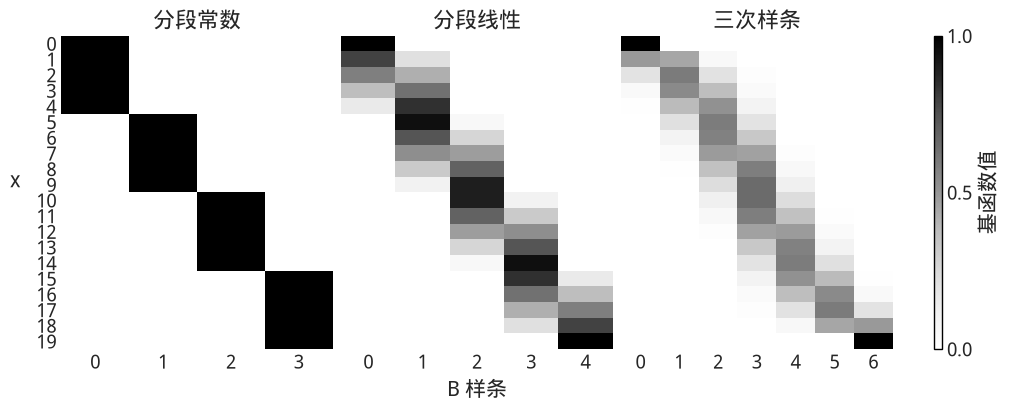

In [10]:
figure, axes = plt.subplots(1, 3, figsize=(10, 4), sharey=True)
image = None
for matrix, title, axis in zip((B0, B1, B3), ("分段常数", "分段线性", "三次样条"), axes, strict=True):
    image = axis.imshow(matrix, cmap="Greys", vmin=0, vmax=1, aspect="auto")
    axis.set_xticks(np.arange(matrix.shape[1]))
    axis.set_yticks(np.arange(matrix.shape[0]))
    axis.spines[["left", "bottom"]].set_visible(False)
    axis.set_title(title)

axes[1].set_xlabel("B 样条")
axes[0].set_ylabel("x", rotation=0, labelpad=15)
figure.colorbar(image, ax=axes, aspect=40, ticks=[0, 0.5, 1], label="基函数值")
figure.savefig(FIGURE_DIR / "design_matrices.png", bbox_inches="tight")

```{figure} figures/design_matrices.png
:name: fig:design_matrices
:width: 8.00in
代码块 [splines_patsy](splines_patsy) 中 Patsy 生成的设计矩阵。颜色从黑色(1)过渡到浅灰色(0)；
列数是 B 样条数量,行数是数据点数量。
```

{numref}`fig:design_matrices` 的第一个子图对应 0 次样条 `B0`。可以看到,设计矩阵只包含 0(浅灰)
和 1(黑色)。第一个 B 样条(第 0 列)对前 5 个观测取 1,其余取 0；第二个 B 样条(第 1 列)对前
5 个观测取 0,对接下来 5 个取 1,之后又回到 0。同样的模式继续重复。把它与
{numref}`fig:splines_weighted` 第一行的第一个子图比较,就能看出设计矩阵如何编码那幅图。

{numref}`fig:design_matrices` 的第二个子图中,第一个 B 样条从 1 降到 0；第二、第三和第四个先从
0 升到 1,再从 1 降到 0；第五个从 0 升到 1。这些模式分别对应
{numref}`fig:splines_weighted` 第一行第二个子图中的负斜率直线、3 个三角函数和正斜率直线。

类似地,可以比较 {numref}`fig:design_matrices` 第三个子图的 7 列与
{numref}`fig:splines_weighted` 第一行第三个子图的 7 条曲线。

代码块 [splines_patsy](splines_patsy) 用于生成 {numref}`fig:splines_weighted` 和
{numref}`fig:design_matrices` 中的 B 样条。唯一差别是前者使用
`x = np.linspace(0., 1., 500)`,所以曲线看起来更平滑；后者使用
`x = np.linspace(0., 1., 20)`,所以矩阵更容易观察。

(splines_patsy_plot)=
**代码块 `splines_patsy_plot`** 对应单元 `ch05-figure-weighted-bsplines`:它逐列绘制基函数,生成
一组正的随机系数 $\beta$,再绘制缩放后的基函数及其总和。系数不必为正；这里取绝对值只是为了得到
原书示例中的先验实现。

到目前为止,我们通过几个例子建立了对样条的直觉,并学习了如何用 Patsy 自动构造样条。接下来要
计算权重,看看如何在 PyMC 的贝叶斯模型中完成这件事。

(fitting-splines-in-pymc3)=

## 在 PyMC 中拟合样条

本节使用 PyMC 拟合一组 B 样条,从而得到回归系数 $\beta$ 的取值。

现代自行车共享系统让世界许多城市中的人们能够以完全自动化的方式租车和还车,提高公共交通效率,
也可能让社会中的一部分人更健康、更快乐。这里使用加州大学欧文分校机器学习资料库中的一个共享
单车数据集 [^12]。目标是估计 24 小时内每个小时租出的自行车数量。先加载并绘制数据。

In [11]:
bikes_all = pd.read_csv(DATA_DIR / "bikes_hour.csv")
source_row_ids = pd.read_csv(
    DATA_DIR / "bikes_authoritative_row_ids.csv",
    dtype={"source_row_id": "int64"},
)["source_row_id"].to_numpy()

# 权威代码先用 pandas 默认快速排序按 hour 排序,再取 [::50]。快速排序不稳定,
# 因此这里直接使用已冻结的原始 CSV 行号,避免 pandas 版本改变同小时内的抽样行。
assert bikes_all.shape == (17379, 17)
assert source_row_ids.shape == (348,)
assert np.unique(source_row_ids).size == source_row_ids.size
assert source_row_ids.min() >= 0 and source_row_ids.max() < len(bikes_all)

# 标准化响应变量；保留原始 count 列供解释尺度上的绘图使用。
data_cnt_om = bikes_all["count"].mean()
data_cnt_os = bikes_all["count"].std()
bikes_all["count_normalized"] = (bikes_all["count"] - data_cnt_om) / data_cnt_os

data = bikes_all.iloc[source_row_ids].copy()
data.insert(0, "source_row_id", source_row_ids)
data.reset_index(drop=True, inplace=True)
assert np.array_equal(data["source_row_id"].to_numpy(), source_row_ids)
assert data["hour"].is_monotonic_increasing
assert tuple(data.groupby("hour", sort=True).size()) == (
    15, 14, 15, 14, 14, 14, 15, 14, 15, 14, 15, 14,
    15, 14, 15, 15, 14, 15, 14, 15, 14, 15, 15, 14,
)
assert np.isclose(data["count"].mean(), 186.19540229885058)

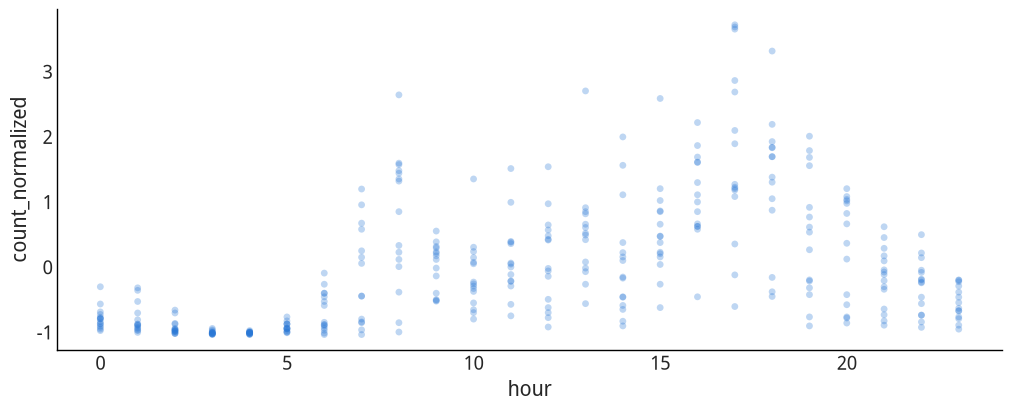

In [12]:
figure, axis = plt.subplots(figsize=(10, 4))
axis.scatter(
    data["hour"],
    data["count_normalized"],
    s=24,
    alpha=0.3,
    color=SERIES_COLORS[0],
    edgecolor="none",
)
axis.set_xlabel("hour")
axis.set_ylabel("count_normalized")
figure.savefig(FIGURE_DIR / "bikes_data.png", bbox_inches="tight")

```{figure} figures/bikes_data.png
:name: fig:bikes_data
:width: 8.00in
自行车数据的可视化。每个点表示一天某个小时(0 到 23)内标准化后的租车数量。点使用半透明样式,
以减少过度重叠,从而更容易看清数据分布。
```

快速查看 {numref}`fig:bikes_data` 就能发现,一天中的小时与租车数量之间的关系很难用一条直线
捕捉。因此,我们尝试用样条回归来逼近这个非线性模式。

前面已经说明,使用样条时需要定义节点的数量和位置。这里使用 6 个节点,并采用最简单的定位方式:
让相邻节点等距。

(knot_list)=
**代码块 `knot_list`** 在下一个单元中定义 6 个内部节点。

In [13]:
num_knots = 6
knot_list = np.linspace(0, 23, num_knots + 2)[1:-1]
assert len(knot_list) == num_knots

代码块 [knot_list](knot_list) 先在端点之间生成 8 个位置,再删除首尾两个位置,因此保留 6 个
位于数据内部的节点。这种策略是否有用取决于数据。如果大部分数据远离边界,通常是合理选择；节点
数量越大,单个节点的具体位置也往往越不重要。

现在用 Patsy 定义并构建设计矩阵。

(bikes_dmatrix)=
**代码块 `bikes_dmatrix`** 使用全部 6 个内部节点。

> **中文版现代化说明**:英文正文说使用 6 个内部节点,但原代码在构造 `knot_list` 后又切片一次,
> 实际只向 Patsy 传入 4 个节点；更新版 Notebook 则直接构造了 4 个节点。中文版以完整正文为权威,
> 构造并传入恰好 6 个内部节点,同时用断言把这一语义固定下来。

In [14]:
B = np.asarray(
    dmatrix(
        "bs(hour, knots=knots, degree=3, include_intercept=True) - 1",
        {"hour": data["hour"].to_numpy(), "knots": knot_list},
    )
)
assert B.shape[0] == len(data)
assert np.allclose(B.sum(axis=1), 1.0)

提出的统计模型为:

```{math}
:label: eq:spline_model
\begin{aligned}
\begin{split}
    \tau \sim& \; \mathcal{HC}(1) \\
    \boldsymbol{\beta} \sim& \; \mathcal{N}(0, \tau) \\
    \sigma \sim& \; \mathcal{HN}(1) \\
    Y \sim& \; \mathcal{N}(\boldsymbol{B}(X)\boldsymbol{\beta},\sigma)
\end{split}\end{aligned}
```

这个样条回归模型与第 [3](chap2) 章的线性模型非常相似。所有困难工作都由设计矩阵
$\boldsymbol{B}$ 及其对特征空间的扩展完成。这里用线性代数记号更简洁地表示式 {eq}`eq:bfr` 和
{eq}`eq:bfr2` 中的乘法与求和,即写成
$\boldsymbol{\mu}=\boldsymbol{B}\boldsymbol{\beta}$,而不是
$\boldsymbol{\mu}=\sum_i^n B_i\boldsymbol{\beta}_i$。

与往常一样,统计语法几乎可以逐行翻译成 PyMC 代码。

(splines)=
**代码块 `splines`** 对应下一个模型单元。

In [15]:
bike_coords = {
    "basis": np.arange(B.shape[1]),
    "bike_obs": np.arange(len(data)),
}
with pm.Model(coords=bike_coords) as bike_spline_model:
    tau = pm.HalfCauchy("τ", 1)
    beta = pm.Normal("β", mu=0, sigma=tau, dims="basis")
    mu = pm.Deterministic("μ", pt.dot(B, beta), dims="bike_obs")
    sigma = pm.HalfNormal("σ", 1)
    count_obs = pm.Normal(
        "c",
        mu=mu,
        sigma=sigma,
        observed=data["count_normalized"].to_numpy(),
        dims="bike_obs",
    )
    idata_s = pm.sample(
        **SAMPLE_KWARGS,
        idata_kwargs={"log_likelihood": True},
    )

Only 20 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [τ, β, σ]


Sampling 1 chain for 20 tune and 20 draw iterations (20 + 20 draws total) took 2 seconds.


The number of samples is too small to check convergence reliably.


> **中文版现代化说明**:模型使用当前 PyMC 的 `sigma=` 参数、PyTensor 的 `pt.dot` 和命名
> `coords`/`dims`。`pm.sample` 直接返回 ArviZ `InferenceData`,并显式保存逐观测对数似然以支持
> 后续 LOO；不再使用 PyMC3 的 `sd=`、`trace` 或 `return_inferencedata=True` 兼容参数。

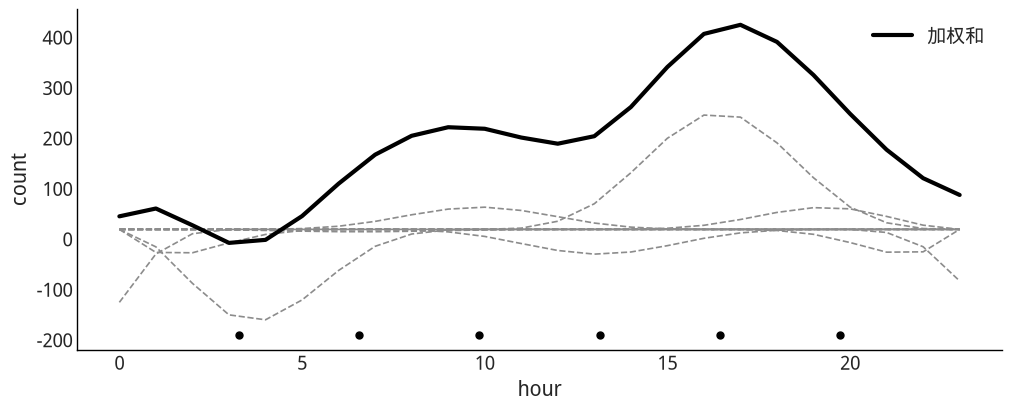

In [16]:
bike_posterior = idata_s.posterior.stack(sample=("chain", "draw"))
beta_mean = bike_posterior["β"].mean("sample").values
mu_mean = bike_posterior["μ"].mean("sample").values

figure, axis = plt.subplots(figsize=(10, 4))
for column_index in range(B.shape[1]):
    axis.plot(
        data["hour"],
        B[:, column_index] * beta_mean[column_index] * data_cnt_os + data_cnt_om / B.shape[1],
        color="0.55",
        linewidth=1.2,
        linestyle="--",
    )
axis.plot(
    data["hour"],
    mu_mean * data_cnt_os + data_cnt_om,
    color="black",
    linewidth=3,
    label="加权和",
)
axis.plot(knot_list, np.full_like(knot_list, axis.get_ylim()[0]), "ko", markersize=5)
axis.set_xlabel("hour")
axis.set_ylabel("count")
axis.legend(frameon=False)
figure.savefig(FIGURE_DIR / "bikes_spline_raw_data.png", bbox_inches="tight")

> **中文版现代化说明**:原更新版代码把反标准化常数 `data_cnt_om` 加到每一个加权基函数上,因此
> 虚线分量之和不再等于黑色总趋势。这里把该常数平均分配给全部基函数,使图中的分量严格相加为
> 后验平均趋势,同时保持 `count` 的原始解释尺度。

{numref}`fig:bikes_spline_raw_data` 用黑色实线展示最终线性预测,并用虚线展示每个加权 B 样条。
这种表示很直观,因为它同时揭示了各个 B 样条对最终结果的贡献。

```{figure} figures/bikes_spline_raw_data.png
:name: fig:bikes_spline_raw_data
:width: 8.00in
用样条拟合自行车数据。虚线表示加权 B 样条,它们的和构成较粗的黑色实线。所绘数值是后验均值,
黑点表示节点。与 {numref}`fig:splines_weighted` 相比,这里的样条看起来更*锯齿状*。原因是本图
只在较少位置计算函数:数据按小时分箱,因此这里只含 24 个不同小时,而
{numref}`fig:splines_weighted` 使用 500 个位置。
```

当目标是展示模型结果时,把原始数据与样条及其不确定性叠加在一起通常更有用,如
{numref}`fig:bikes_data2` 所示。从图中很容易看出,深夜租车数量最低；随后数量上升,可能对应人们
起床通勤。大约 10 点出现第一个峰值,之后趋于平缓或略有下降；大约 18 点人们下班回家时出现
第二个峰值,再往后则持续下降。

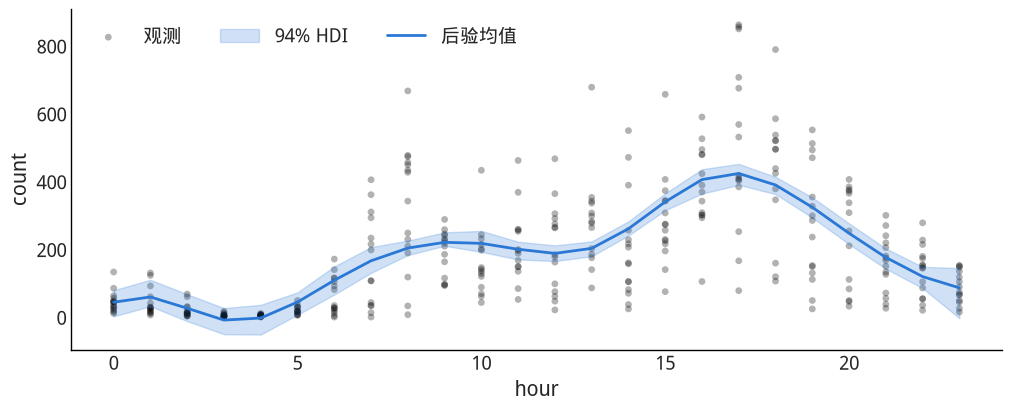

In [17]:
mu_da = idata_s.posterior["μ"] * data_cnt_os + data_cnt_om
mu_mean_original = mu_da.mean(dim=("chain", "draw")).values
mu_hdi = az.hdi(mu_da, hdi_prob=0.94)["μ"].values

figure, axis = plt.subplots(figsize=(10, 4))
axis.scatter(
    data["hour"],
    data["count"],
    s=24,
    alpha=0.3,
    color="black",
    edgecolor="none",
    label="观测",
)
axis.fill_between(
    data["hour"],
    mu_hdi[:, 0],
    mu_hdi[:, 1],
    color=SERIES_COLORS[0],
    alpha=0.22,
    label="94% HDI",
)
axis.plot(
    data["hour"],
    mu_mean_original,
    color=SERIES_COLORS[0],
    linewidth=2,
    label="后验均值",
)
axis.set_xlabel("hour")
axis.set_ylabel("count")
axis.legend(frameon=False, ncol=3)
figure.savefig(FIGURE_DIR / "bikes_spline_data.png", bbox_inches="tight")

```{figure} figures/bikes_spline_data.png
:name: fig:bikes_data2
:width: 8.00in
用样条拟合自行车数据(黑点)。阴影表示均值函数的 94% 最高密度区间(highest density interval,
HDI),蓝线表示平均趋势。
```

自行车租赁例子中的“小时”是一个循环变量,也就是说 0 点与 24 点相同。对人而言这可能很明显,
但模型并不会自动知道。Patsy 提供了一个简单办法来告诉模型该变量是循环的:构建设计矩阵时用
`cc` 代替 `bs`。`cc` 是能够感知循环边界的三次样条。建议阅读 Patsy 文档了解更多细节,并在
前面的模型中尝试 `cc`,比较结果。

(choosing-knots-and-prior-for-splines)=

## 为样条选择节点与先验

使用样条时必须做出的一项建模决策,是选择节点数量和位置。一般而言,节点数量与间距并没有显而易见
的答案,这可能令人不安。面对这类选择,可以拟合多个模型,再用留一法交叉验证(leave-one-out
cross-validation, LOO)等方法帮助选择。

{numref}`tab:loo_splines` 明确标为**原书历史发布结果**:当时类似代码块 [splines](splines) 的模型
分别使用 3、6、9、12 和 18 个等距节点,LOO 把 12 节点样条排在第一。表中 `m_12k` 的堆叠权重为
0.88,`m_3k` 为 0.12,其余模型接近 0。正如 {ref}`model_averaging` 节所解释的,堆叠试图组合多个
模型,尽量减小组合预测与*真实*生成模型之间的散度。因此在那次历史运行中,虽然 `m_6k`、`m_9k`
和 `m_18k` 的 `loo` 值优于 `m_3k`,但加入 `m_12k` 后它们几乎没有新增贡献,而排名最低的
`m_3k` 仍提供了一些不同信息。

当前代码会用冻结的权威样本和所选执行配置重新计算 `bike_comparison`。`smoke` 结果只用于验证路径,
不能据此选择节点；发布判断必须来自 `CH5_PROFILE=release` 的新输出。
{numref}`fig:bikes_spline_loo_knots` 展示当前运行中这些模型的后验平均样条,并根据当前比较结果决定强调
哪条曲线,不把历史排名硬编码进图。

In [18]:
num_knots_grid = (3, 6, 9, 12, 18)
bike_designs = []
bike_knot_lists = []
bike_idatas = []

for knot_count in num_knots_grid:
    candidate_knots = np.linspace(0, 24, knot_count + 2)[1:-1]
    candidate_design = np.asarray(
        dmatrix(
            "bs(hour, knots=knots, degree=3, include_intercept=True) - 1",
            {"hour": data["hour"].to_numpy(), "knots": candidate_knots},
        )
    )
    assert candidate_design.shape == (len(data), knot_count + 4)
    assert np.linalg.matrix_rank(candidate_design) == candidate_design.shape[1]
    assert np.allclose(candidate_design.sum(axis=1), 1.0)
    bike_knot_lists.append(candidate_knots)
    bike_designs.append(candidate_design)

    candidate_coords = {
        "basis": np.arange(candidate_design.shape[1]),
        "bike_obs": np.arange(len(data)),
    }
    with pm.Model(coords=candidate_coords) as candidate_model:
        tau = pm.HalfCauchy("τ", 1)
        beta = pm.Normal("β", mu=0, sigma=tau, dims="basis")
        mu = pm.Deterministic("μ", pt.dot(candidate_design, beta), dims="bike_obs")
        sigma = pm.HalfNormal("σ", 1)
        pm.Normal(
            "c",
            mu=mu,
            sigma=sigma,
            observed=data["count_normalized"].to_numpy(),
            dims="bike_obs",
        )
        candidate_idata = pm.sample(
            **COMPARE_SAMPLE_KWARGS,
            idata_kwargs={"log_likelihood": True},
        )
    bike_idatas.append(candidate_idata)

bike_models = {
    f"m_{knot_count}k": idata
    for knot_count, idata in zip(num_knots_grid, bike_idatas, strict=True)
}
bike_comparison = az.compare(bike_models)
assert set(bike_comparison.index) == set(bike_models)
assert sorted(bike_comparison["rank"].astype(int).tolist()) == list(range(len(bike_models)))
bike_comparison.round(2)

Only 12 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [τ, β, σ]


Sampling 1 chain for 12 tune and 12 draw iterations (12 + 12 draws total) took 1 seconds.


...

Sampling 1 chain for 12 tune and 12 draw iterations (12 + 12 draws total) took 2 seconds.


The number of samples is too small to check convergence reliably.


/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.07 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.07 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/ai/Projects/BookCo

/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.07 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(


,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,scale
m_12k,0,-357.51,9.61,0.00,0.78,18.72,0.00,True,log
m_9k,1,-362.25,11.40,4.75,0.00,18.42,2.35,True,log
m_18k,2,-362.44,17.09,4.94,0.06,18.22,2.89,True,log
m_6k,3,-366.20,8.85,8.70,0.00,19.04,4.91,True,log
m_3k,4,-378.68,5.35,21.17,0.16,18.67,8.43,True,log


> **中文版现代化说明**:静态表 5.1 是原书未改写时的历史发布结果,保留当时的列名 `loo`、
> `d_loo` 和数值以维护引用与可追溯性,不冒充当前运行输出。当前 ArviZ 报告 `elpd_loo`、
> `elpd_diff` 等列名；随机数生成器、采样器和版本变化也会带来数值差异。中文版已冻结权威代码
> `sort_values(by="hour")[::50]` 在验证环境得到的原始 CSV 行号,避免非稳定排序继续改变样本；
> `smoke` 仍只验证完整路径,发布比较必须使用 `CH5_PROFILE=release` 并以该单元的新输出为准。

```{list-table} 原书历史发布运行中使用 LOO 比较不同节点数量样条模型的摘要。
:name: tab:loo_splines
* -
  - **rank**
  - **loo**
  - **p_loo**
  - **d_loo**
  - **weight**
  - **se**
  - **dse**
  - **warning**
  - **loo_scale**
* - m_12k
  - 0
  - -377.67
  - 14.21
  - 0.00
  - 0.88
  - 17.86
  - 0.00
  - False
  - log
* - m_18k
  - 1
  - -379.78
  - 17.56
  - 2.10
  - 0.00
  - 17.89
  - 1.45
  - False
  - log
* - m_9k
  - 2
  - -380.42
  - 11.43
  - 2.75
  - 0.00
  - 18.12
  - 2.97
  - False
  - log
* - m_6k
  - 3
  - -389.43
  - 9.41
  - 11.76
  - 0.00
  - 18.16
  - 5.72
  - False
  - log
* - m_3k
  - 4
  - -400.25
  - 7.17
  - 22.58
  - 0.12
  - 18.01
  - 7.78
  - False
  - log
```

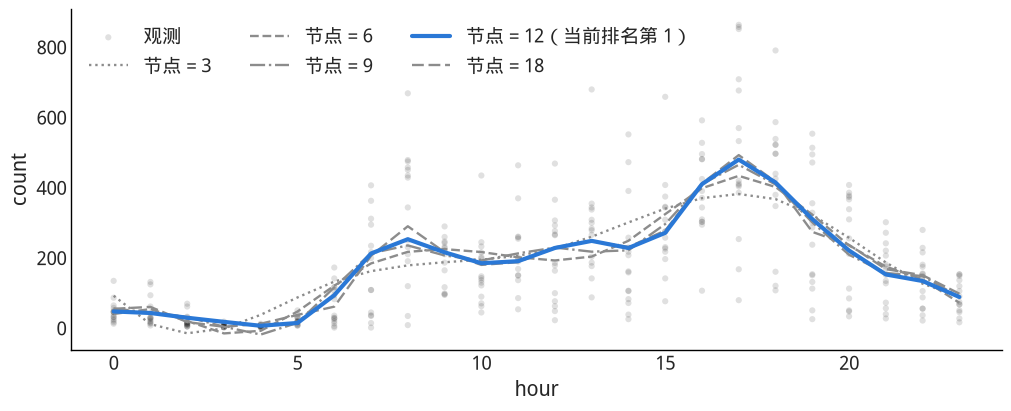

In [19]:
figure, axis = plt.subplots(figsize=(10, 4))
axis.scatter(
    data["hour"],
    data["count"],
    s=20,
    alpha=0.12,
    color="black",
    edgecolor="none",
    label="观测",
)

bike_model_names = [f"m_{knot_count}k" for knot_count in num_knots_grid]
bike_winner_name = str(bike_comparison["rank"].astype(int).idxmin())
assert bike_winner_name in bike_model_names

for knot_count, model_name, idata, secondary_linestyle in zip(
    num_knots_grid,
    bike_model_names,
    bike_idatas,
    (":", "--", "-.", (0, (3, 1, 1, 1)), (0, (5, 2))),
    strict=True,
):
    mean_function = idata.posterior["μ"].mean(dim=("chain", "draw")).values
    is_winner = model_name == bike_winner_name
    axis.plot(
        data["hour"],
        mean_function * data_cnt_os + data_cnt_om,
        color=SERIES_COLORS[0] if is_winner else "0.55",
        linestyle="-" if is_winner else secondary_linestyle,
        linewidth=3 if is_winner else 1.7,
        zorder=3 if is_winner else 2,
        label=(
            f"节点 = {knot_count}（当前排名第 1）"
            if is_winner
            else f"节点 = {knot_count}"
        ),
    )

axis.set_xlabel("hour")
axis.set_ylabel("count")
axis.legend(ncol=3, frameon=False)
figure.savefig(FIGURE_DIR / "bikes_spline_loo_knots.png", bbox_inches="tight")

```{figure} figures/bikes_spline_loo_knots.png
:name: fig:bikes_spline_loo_knots
:width: 8.00in
代码块 [splines](splines) 所描述模型在使用不同节点数(3、6、9、12、18)时的后验平均样条。
图对应当前 `CH5_PROFILE` 运行:当前 LOO 排名第一的模型以蓝色粗实线强调,其余模型以不同线型的
灰线显示。图例直接标出当前第一名,因此不会把 {numref}`tab:loo_splines` 的历史排名硬编码进新图。
`smoke` 图仅用于执行检查,模型选择应查看新的 `release` 输出。
```

有一条可能有助于确定节点位置的建议:按分位数而不是等距放置节点。代码块 [knot_list](knot_list)
中的 `knot_list` 也可以定义为
`np.quantile(data.hour, np.linspace(0, 1, num_knots))`。这样,数据较密集处会放置更多节点,数据
较稀疏处会放置更少节点,从而让数据丰富的区域获得更灵活的近似。

(regularizing-prior-for-splines)=

### 样条的正则化先验

节点太少可能导致欠拟合,节点太多又可能导致过拟合,因此一种策略是使用*相当多*的节点,再选择一个
正则化先验。从样条定义和 {numref}`fig:splines_weighted` 可以看到,相邻
$\boldsymbol{\beta}$ 系数越接近,结果函数越平滑。想象从
{numref}`fig:splines_weighted` 的设计矩阵中删除相邻两列,等价于把相应系数设为 0。因为预测变量
没有足够信息覆盖某个局部区域(记住样条具有*局部性*),拟合会明显变得不平滑。因此,可以为
$\boldsymbol{\beta}$ 系数选择一种先验,使 $\beta_{i+1}$ 与 $\beta_i$ 的取值相关,从而得到更平滑
的回归曲线:

```{math}
:label: eq:spline_regularized_prior
\begin{aligned}
\begin{split}
\beta_i \sim& \mathcal{N}(0, 1) \\
\tau\sim& \mathcal{N}(0,1) \\
\beta \sim& \mathcal{N}(\beta_{i-1}, \tau)
\end{split}\end{aligned}
```

使用 PyMC,可以借助高斯随机游走(Gaussian Random Walk, GRW)先验写出等价版本:

```{math}
:label: eq:spline_regularized_GW_prior
\begin{aligned}
\begin{split}
\tau\sim& \mathcal{N}(0, 1) \\
\beta \sim& \mathcal{G}RW(\beta, \tau)
\end{split}\end{aligned}
```

为了观察这个先验的作用,再次分析自行车数据。英文正文在这里写 `num_knots = 12`,而图注与更新版
代码使用 22 个内部节点。下面同时拟合带 GRW 平滑先验的模型和使用独立高斯系数的模型。

(splines_rw)=
**代码块 `splines_rw`** 对应下一个模型单元。

> **中文版现代化说明**:为与原图注及更新版 Notebook 的可执行行为一致,本节使用
> `np.arange(1, 23)`,即 22 个内部节点。当前 PyMC 的 `GaussianRandomWalk` 还显式指定
> `init_dist=pm.Normal.dist(0, 1)`,避免依赖已弃用的隐式初始分布。
>
> **中文版补充**:上面两条公式逐字保留原书记号,其中把尺度参数 $\tau$ 写成可取负值的正态分布,
> 且 GRW 公式存在自指记号。可执行模型沿用原书代码的正尺度半柯西先验,以保持尺度参数语义有效。

In [20]:
regularized_knots = np.arange(1, 23)
B_regularized = np.asarray(
    dmatrix(
        "bs(hour, knots=knots, degree=3, include_intercept=True) - 1",
        {"hour": data["hour"].to_numpy(), "knots": regularized_knots},
    )
)
assert len(regularized_knots) == 22
assert B_regularized.shape[1] == 26
assert np.linalg.matrix_rank(B_regularized) == 24

> **中文版补充**:小时变量只有 24 个不同取值,而 22 个内部节点的三次样条产生 26 列设计矩阵,
> 其秩为 24。因此数据似然无法单独识别两个系数方向；独立高斯先验或 GRW 先验会正则化这些方向,
> 但不应把 26 个系数解释成 26 个由数据独立识别的效应。

In [21]:
regularized_coords = {
    "basis": np.arange(B_regularized.shape[1]),
    "bike_obs": np.arange(len(data)),
}
with pm.Model(coords=regularized_coords) as bike_grw_model:
    tau = pm.HalfCauchy("τ", 1)
    beta = pm.GaussianRandomWalk(
        "β",
        sigma=tau,
        init_dist=pm.Normal.dist(mu=0, sigma=1),
        dims="basis",
    )
    mu = pm.Deterministic("μ", pt.dot(B_regularized, beta), dims="bike_obs")
    sigma = pm.HalfNormal("σ", 1)
    pm.Normal(
        "c",
        mu=mu,
        sigma=sigma,
        observed=data["count_normalized"].to_numpy(),
        dims="bike_obs",
    )
    idata_splines_rw = pm.sample(
        **SAMPLE_KWARGS,
        idata_kwargs={"log_likelihood": True},
    )
    idata_splines_rw = pm.sample_posterior_predictive(
        idata_splines_rw,
        random_seed=SEED + 1,
        progressbar=False,
        extend_inferencedata=True,
    )

Only 20 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [τ, β, σ]


Sampling 1 chain for 20 tune and 20 draw iterations (20 + 20 draws total) took 4 seconds.


The number of samples is too small to check convergence reliably.


Sampling: [c]


In [22]:
with pm.Model(coords=regularized_coords) as bike_wiggly_model:
    tau = pm.HalfCauchy("τ", 1)
    beta = pm.Normal("β", mu=0, sigma=tau, dims="basis")
    mu = pm.Deterministic("μ", pt.dot(B_regularized, beta), dims="bike_obs")
    sigma = pm.HalfNormal("σ", 1)
    pm.Normal(
        "c",
        mu=mu,
        sigma=sigma,
        observed=data["count_normalized"].to_numpy(),
        dims="bike_obs",
    )
    idata_wiggly = pm.sample(
        **SAMPLE_KWARGS,
        idata_kwargs={"log_likelihood": True},
    )
    idata_wiggly = pm.sample_posterior_predictive(
        idata_wiggly,
        random_seed=SEED + 2,
        progressbar=False,
        extend_inferencedata=True,
    )

Only 20 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [τ, β, σ]


Sampling 1 chain for 20 tune and 20 draw iterations (20 + 20 draws total) took 4 seconds.


The number of samples is too small to check convergence reliably.


Sampling: [c]


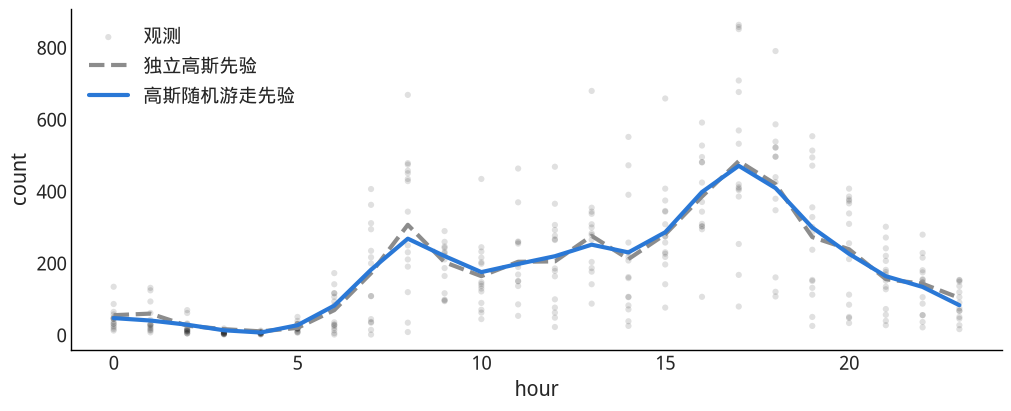

In [23]:
wiggly_mean = (
    idata_wiggly.posterior["μ"].mean(dim=("chain", "draw")).values * data_cnt_os
    + data_cnt_om
)
grw_mean = (
    idata_splines_rw.posterior["μ"].mean(dim=("chain", "draw")).values * data_cnt_os
    + data_cnt_om
)

figure, axis = plt.subplots(figsize=(10, 4))
axis.scatter(
    data["hour"],
    data["count"],
    s=20,
    alpha=0.12,
    color="black",
    edgecolor="none",
    label="观测",
)
axis.plot(
    data["hour"],
    wiggly_mean,
    color="0.55",
    linewidth=3,
    linestyle="--",
    label="独立高斯先验",
)
axis.plot(
    data["hour"],
    grw_mean,
    color=SERIES_COLORS[0],
    linewidth=3,
    label="高斯随机游走先验",
)
axis.set_xlabel("hour")
axis.set_ylabel("count")
axis.legend(frameon=False)
figure.savefig(FIGURE_DIR / "bikes_spline_data_grw.png", bbox_inches="tight")

从 {numref}`fig:bikes_spline_data_grw` 可以看到,`bike_grw_model` 的蓝色实线比
`bike_wiggly_model` 的灰色虚线更少曲折,虽然这里的差异确实比较小。

```{figure} figures/bikes_spline_data_grw.png
:name: fig:bikes_spline_data_grw
:width: 8.00in
使用独立高斯先验或正则化高斯随机游走先验(GRW)拟合自行车数据。两个模型都使用 22 个内部节点。
灰色虚线是 `bike_wiggly_model` 的独立高斯系数先验拟合,蓝色实线是 `bike_grw_model` 的 GRW
平滑先验拟合；图例同时给出线型编码。
```

> **中文版现代化说明**:英文正文和图注对 Figure 5.11 的颜色描述相互冲突。中文版固定为“独立
> 高斯先验 = 灰色虚线,GRW = 蓝色实线”,并用图例和线型提供非颜色编码。

(modeling-co2-uptake-with-splines)=

## 用样条建模 CO₂ 吸收量

作为最后一个样条例子,我们使用一项实验研究的数据 {cite:p}`Potvin1990, Pedersen2019`。实验在
不同条件下测量 12 株植物的 CO₂ 吸收量。本节只研究外部 CO₂ 浓度的影响,也就是环境中的 CO₂
浓度如何影响不同植物对 CO₂ 的吸收。每株植物都在 7 个 CO₂ 浓度下测量吸收量,而且 12 株植物
使用同样的 7 个浓度。先加载并整理数据。

(plants_co2_import)=
**代码块 `plants_co2_import`** 对应下一个单元。

In [24]:
plants_CO2 = pd.read_csv(DATA_DIR / "CO2_uptake.csv")
plant_names = plants_CO2["Plant"].unique()

# 每株植物的前 7 个 CO2 浓度相同。
CO2_conc = plants_CO2["conc"].to_numpy()[:7]
CO2_concs = plants_CO2["conc"].to_numpy()
uptake = plants_CO2["uptake"].to_numpy()

index = np.arange(len(plant_names))
groups = len(index)
assert plants_CO2.shape == (84, 5)
assert groups == 12

第一个模型只有一条响应曲线,也就是假设 12 株植物共享同一条响应曲线。首先像前面一样用 Patsy
定义设计矩阵。因为每株植物只有 7 个观测,所以设 `num_knots=2`,较少的节点应当已经足够。代码块
[plants_co2_import](plants_co2_import) 中,`CO2_concs` 包含
`[95, 175, 250, 350, 500, 675, 1000]` 这组值,并为 12 株植物重复 12 次。

In [25]:
num_knots = 2
co2_knots = np.linspace(CO2_conc[0], CO2_conc[-1], num_knots + 2)[1:-1]

Bg = np.asarray(
    dmatrix(
        "bs(conc, knots=knots, degree=3, include_intercept=True) - 1",
        {"conc": CO2_concs, "knots": co2_knots},
    )
)
assert Bg.shape[0] == len(uptake)

这个问题与前面自行车租赁问题相似,所以可以从同一个模型开始。使用已经在其他问题中应用过的模型,
或使用从文献中学到的模型,通常是分析的良好起点。这种**模型模板(model template)** 方法可以看作
模型设计漫长过程的一条捷径 {cite:p}`Gelman2020`。除了无需从零构思模型这一明显优势之外,它还
带来其他好处:我们对如何开展模型的探索性分析会有更好的直觉,也更容易想到如何修改模型,无论是
简化它还是增加复杂度。

(sp_global)=
**代码块 `sp_global`** 对应下一个单元。

In [26]:
co2_global_coords = {
    "co2_basis": np.arange(Bg.shape[1]),
    "co2_obs": np.arange(len(uptake)),
}
with pm.Model(coords=co2_global_coords) as sp_global_model:
    tau = pm.HalfCauchy("τ", 1)
    beta = pm.Normal("β", mu=0, sigma=tau, dims="co2_basis")
    mu_g = pm.Deterministic("μg", pt.dot(Bg, beta), dims="co2_obs")
    sigma = pm.HalfNormal("σ", 1)
    pm.Normal("up", mu=mu_g, sigma=sigma, observed=uptake, dims="co2_obs")
    idata_sp_global = pm.sample(
        **SAMPLE_KWARGS,
        idata_kwargs={"log_likelihood": True},
    )

Only 20 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [τ, β, σ]


Sampling 1 chain for 20 tune and 20 draw iterations (20 + 20 draws total) took 26 seconds.


Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


The number of samples is too small to check convergence reliably.


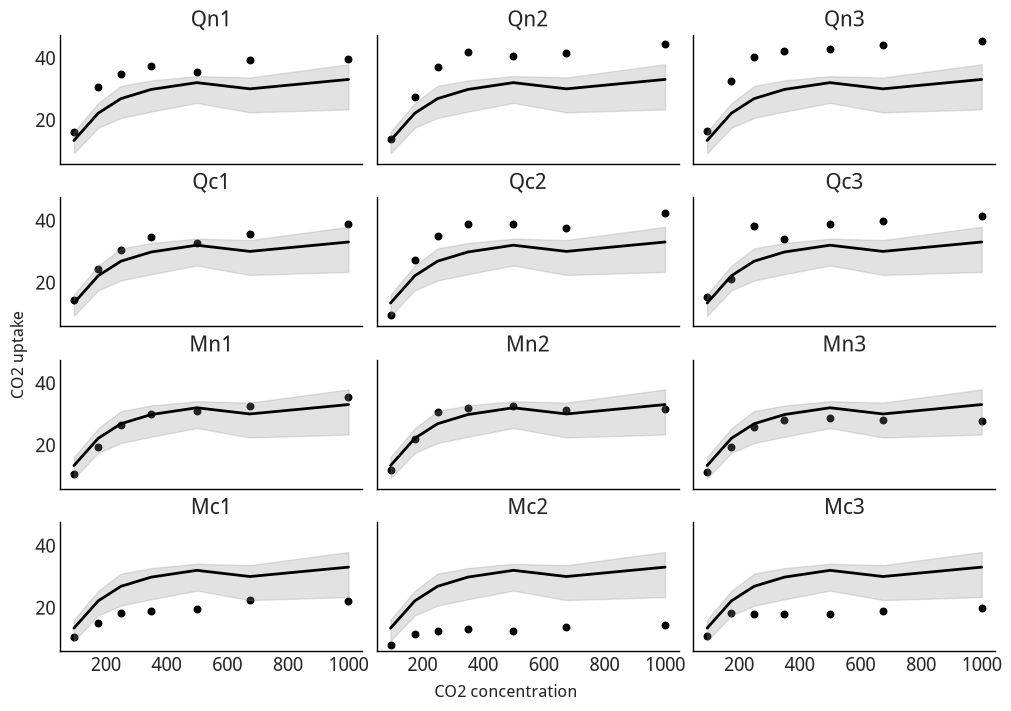

In [27]:
mu_global_da = idata_sp_global.posterior["μg"]
mu_global_mean = mu_global_da.mean(dim=("chain", "draw")).values
mu_global_hdi = az.hdi(mu_global_da, hdi_prob=0.94)["μg"].values

figure, axes = plt.subplots(4, 3, figsize=(10, 7), sharex=True, sharey=True)
for plant_index, (start, axis) in enumerate(zip(range(0, 84, 7), axes.ravel(), strict=True)):
    stop = start + 7
    axis.scatter(CO2_conc, uptake[start:stop], s=22, color="black", label="观测")
    axis.fill_between(
        CO2_conc,
        mu_global_hdi[start:stop, 0],
        mu_global_hdi[start:stop, 1],
        color="0.55",
        alpha=0.25,
        label="94% HDI",
    )
    axis.plot(CO2_conc, mu_global_mean[start:stop], color="black", linewidth=2)
    axis.set_title(plant_names[plant_index])

figure.supxlabel("CO2 concentration")
figure.supylabel("CO2 uptake")
figure.savefig(FIGURE_DIR / "sp_global.png", bbox_inches="tight")

从 {numref}`fig:sp_global` 可以清楚看到,模型只对部分植物提供了良好拟合。把所有植物合并在一起时,
模型平均而言表现不错,但对具体植物的拟合并不好。

```{figure} figures/sp_global.png
:name: fig:sp_global
:width: 8.00in
黑点表示 12 株植物(Qn1、Qn2、Qn3、Qc1、Qc2、Qc3、Mn1、Mn2、Mn3、Mc1、Mc2、Mc3)分别在
7 个 CO₂ 浓度下测得的 CO₂ 吸收量。黑线是代码块 [sp_global](sp_global) 中模型的平均样条拟合,
灰色阴影表示该拟合的 94% HDI。
```

现在尝试让每株植物拥有不同响应。为此,在代码块 [Bi_matrix](Bi_matrix) 中定义设计矩阵 `Bi`。
构造 `Bi` 时使用 `CO2_conc = [95, 175, 250, 350, 500, 675, 1000]`,因此它只有 7 行；`Bg`
则有 84 行。

(Bi_matrix)=
**代码块 `Bi_matrix`** 对应下一个单元。

In [28]:
Bi = np.asarray(
    dmatrix(
        "bs(conc, knots=knots, degree=3, include_intercept=True) - 1",
        {"conc": CO2_conc, "knots": co2_knots},
    )
)
assert Bi.shape == (7, 6)
assert np.allclose(Bi.sum(axis=1), 1.0)

> **中文版现代化说明**:英文正文把 `Bi` 写成 $7\times7$。在当前 Patsy 中,2 个内部节点、3 次样条、
> `include_intercept=True` 并用 `- 1` 去除公式截距时,设计矩阵是 $7\times6$。中文版保留“7 行
> 对应 7 个浓度”的教学意图,并以运行时断言记录实际列数由 Patsy 基函数规则决定。

按照 `Bi` 的形状,代码块 [sp_individual](sp_individual) 中参数 $\beta$ 的形状现在为
`(Bi.shape[1], groups)`,而不再是 `(Bg.shape[1],)`。然后把 `μi` 转置并展平,使 12 株植物各自的
7 个均值与 `uptake` 的观测顺序一致。

(sp_individual)=
**代码块 `sp_individual`** 对应下一个单元。

In [29]:
co2_individual_coords = {
    "co2_basis": np.arange(Bi.shape[1]),
    "plant": plant_names,
    "co2_level": CO2_conc,
    "co2_obs": np.arange(len(uptake)),
}
with pm.Model(coords=co2_individual_coords) as sp_individual_model:
    tau = pm.HalfCauchy("τ", 1)
    beta_i = pm.Normal("βi", mu=0, sigma=tau, dims=("co2_basis", "plant"))
    mu_i = pm.Deterministic("μi", pt.dot(Bi, beta_i), dims=("co2_level", "plant"))
    individual_mean = pt.reshape(pt.transpose(mu_i), (len(uptake),))
    sigma = pm.HalfNormal("σ", 1)
    pm.Normal("up", mu=individual_mean, sigma=sigma, observed=uptake, dims="co2_obs")
    idata_sp_individual = pm.sample(
        **SAMPLE_KWARGS,
        idata_kwargs={"log_likelihood": True},
    )

Only 20 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [τ, βi, σ]


Sampling 1 chain for 20 tune and 20 draw iterations (20 + 20 draws total) took 13 seconds.


The number of samples is too small to check convergence reliably.


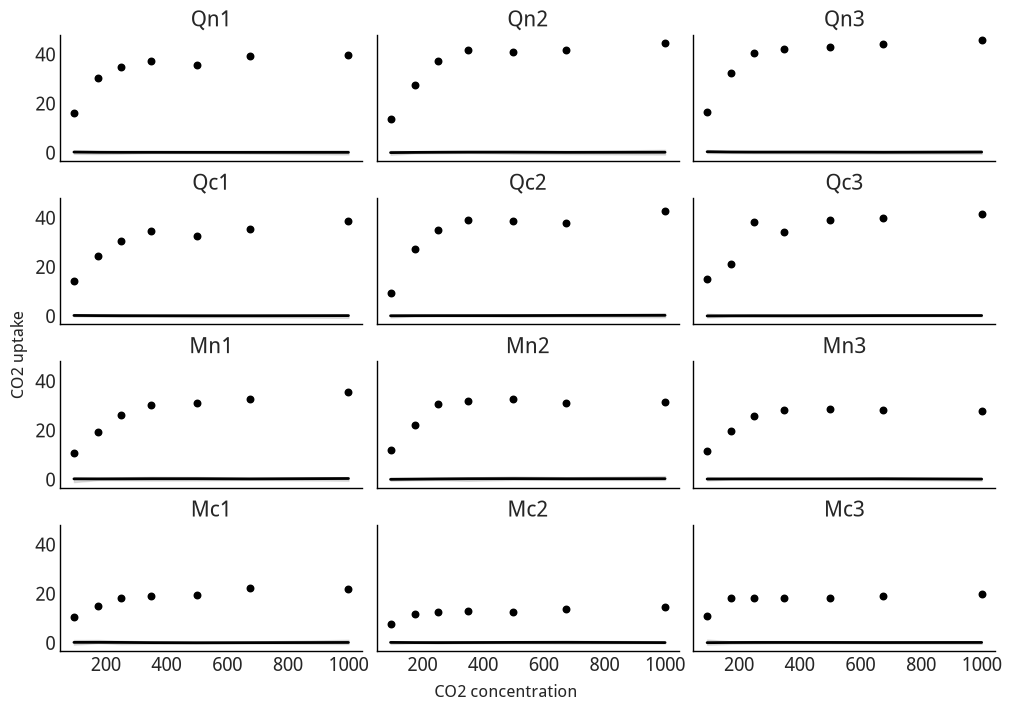

In [30]:
mu_individual_da = idata_sp_individual.posterior["μi"]
mu_individual_mean = mu_individual_da.mean(dim=("chain", "draw")).values
mu_individual_hdi = az.hdi(mu_individual_da, hdi_prob=0.94)["μi"].values

figure, axes = plt.subplots(4, 3, figsize=(10, 7), sharex=True, sharey=True)
for plant_index, (start, axis) in enumerate(zip(range(0, 84, 7), axes.ravel(), strict=True)):
    stop = start + 7
    axis.scatter(CO2_conc, uptake[start:stop], s=22, color="black")
    axis.fill_between(
        CO2_conc,
        mu_individual_hdi[:, plant_index, 0],
        mu_individual_hdi[:, plant_index, 1],
        color="0.55",
        alpha=0.25,
    )
    axis.plot(CO2_conc, mu_individual_mean[:, plant_index], color="black", linewidth=2)
    axis.set_title(plant_names[plant_index])

figure.supxlabel("CO2 concentration")
figure.supylabel("CO2 uptake")
figure.savefig(FIGURE_DIR / "sp_individual.png", bbox_inches="tight")

从 {numref}`fig:sp_individual` 可以看到,现在对每株植物的拟合都好得多。

```{figure} figures/sp_individual.png
:name: fig:sp_individual
:width: 8.00in
12 株植物在 7 个 CO₂ 浓度下测得的 CO₂ 吸收量。黑线是代码块
[sp_individual](sp_individual) 中模型的平均样条拟合,灰色阴影表示该拟合的 94% HDI。
```

也可以混合前两个模型 [^13]。如果希望同时估计 12 株植物的全局趋势和各自拟合,这种做法会很有
吸引力。代码块 [sp_mix](sp_mix) 中的 `sp_mix` 模型同时使用前面定义的 `Bg` 与 `Bi` 两个设计
矩阵。

(sp_mix)=
**代码块 `sp_mix`** 对应下一个单元。

In [31]:
co2_mixed_coords = {
    "global_basis": np.arange(Bg.shape[1]),
    "individual_basis": np.arange(Bi.shape[1]),
    "plant": plant_names,
    "co2_level": CO2_conc,
    "co2_obs": np.arange(len(uptake)),
}
with pm.Model(coords=co2_mixed_coords) as sp_mix_model:
    tau = pm.HalfCauchy("τ", 1)
    beta_g = pm.Normal("βg", mu=0, sigma=tau, dims="global_basis")
    mu_g = pm.Deterministic("μg", pt.dot(Bg, beta_g), dims="co2_obs")

    beta_i_raw = pm.Normal(
        "βi_raw",
        mu=0,
        sigma=tau,
        dims=("individual_basis", "plant"),
    )
    beta_i = pm.Deterministic(
        "βi",
        beta_i_raw - pt.mean(beta_i_raw, axis=1, keepdims=True),
        dims=("individual_basis", "plant"),
    )
    mu_i = pm.Deterministic("μi", pt.dot(Bi, beta_i), dims=("co2_level", "plant"))
    individual_mean = pt.reshape(pt.transpose(mu_i), (len(uptake),))

    sigma = pm.HalfNormal("σ", 1)
    pm.Normal(
        "up",
        mu=mu_g + individual_mean,
        sigma=sigma,
        observed=uptake,
        dims="co2_obs",
    )
    idata_sp_mix = pm.sample(
        **SAMPLE_KWARGS,
        idata_kwargs={"log_likelihood": True},
    )

mix_centering_residual = np.abs(idata_sp_mix.posterior["βi"].sum(dim="plant")).max().item()
assert mix_centering_residual < 1e-10

Only 20 samples per chain. Reliable r-hat and ESS diagnostics require longer chains for accurate estimate.


Initializing NUTS using jitter+adapt_diag...


Sequential sampling (1 chains in 1 job)


NUTS: [τ, βg, βi_raw, σ]


Sampling 1 chain for 20 tune and 20 draw iterations (20 + 20 draws total) took 49 seconds.


Chain 0 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.


The number of samples is too small to check convergence reliably.


> **中文版现代化说明**:原 `sp_mix` 的全局 6 个基函数完全落在 12 组单株基函数的列空间中,因此
> 似然只能识别每株植物的总曲线,不能唯一分解“全局 + 单株偏离”。这里把每个基函数上的 12 个
> 单株系数约束为和为 0,消除 6 个精确不可识别方向,使黑色全局趋势与灰色偏离的分解具有明确含义。

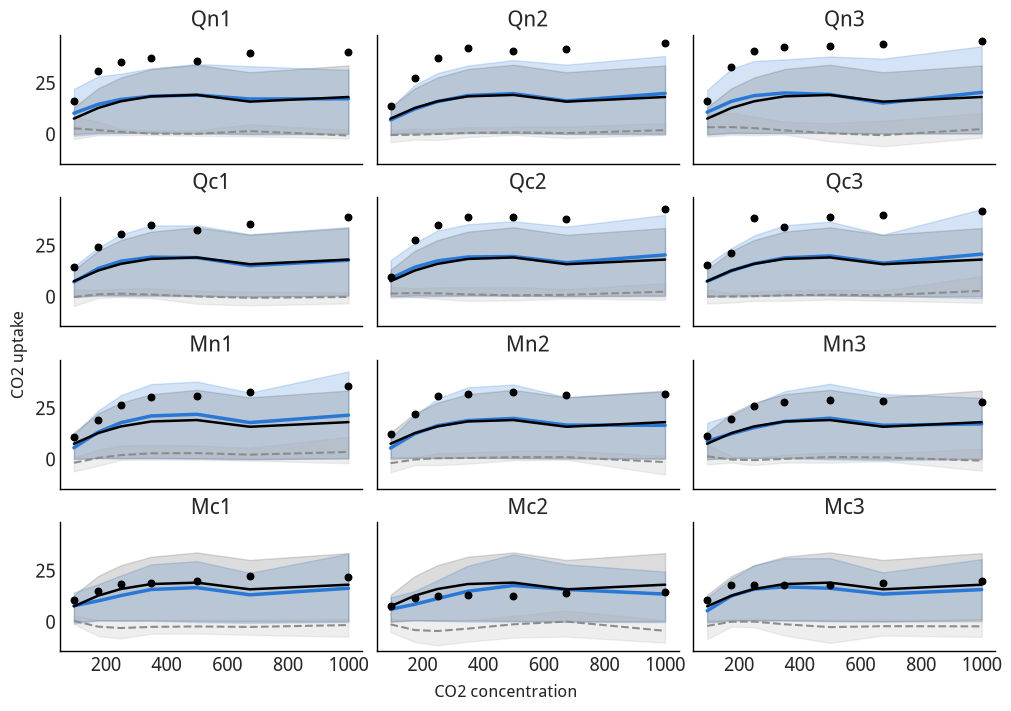

In [32]:
mix_global_da = idata_sp_mix.posterior["μg"]
mix_individual_da = idata_sp_mix.posterior["μi"]
mix_global_hdi = az.hdi(mix_global_da, hdi_prob=0.94)["μg"].values
mix_individual_hdi = az.hdi(mix_individual_da, hdi_prob=0.94)["μi"].values

figure, axes = plt.subplots(4, 3, figsize=(10, 7), sharex=True, sharey=True)
for plant_index, (start, axis) in enumerate(zip(range(0, 84, 7), axes.ravel(), strict=True)):
    stop = start + 7
    global_da = (
        mix_global_da.isel(co2_obs=slice(start, stop))
        .rename({"co2_obs": "co2_level"})
        .assign_coords(co2_level=CO2_conc)
    )
    individual_da = mix_individual_da.sel(plant=plant_names[plant_index])
    total_da = global_da + individual_da
    total_da.name = "μ_total"
    total_hdi = az.hdi(total_da, hdi_prob=0.94)["μ_total"].values

    axis.scatter(CO2_conc, uptake[start:stop], s=22, color="black", zorder=3)
    axis.fill_between(
        CO2_conc,
        total_hdi[:, 0],
        total_hdi[:, 1],
        color=SERIES_COLORS[0],
        alpha=0.2,
    )
    axis.plot(
        CO2_conc,
        total_da.mean(dim=("chain", "draw")).values,
        color=SERIES_COLORS[0],
        linewidth=2.5,
    )

    axis.fill_between(
        CO2_conc,
        mix_global_hdi[start:stop, 0],
        mix_global_hdi[start:stop, 1],
        color="0.25",
        alpha=0.18,
    )
    axis.plot(
        CO2_conc,
        global_da.mean(dim=("chain", "draw")).values,
        color="black",
        linewidth=1.8,
    )

    axis.fill_between(
        CO2_conc,
        mix_individual_hdi[:, plant_index, 0],
        mix_individual_hdi[:, plant_index, 1],
        color="0.65",
        alpha=0.18,
    )
    axis.plot(
        CO2_conc,
        individual_da.mean(dim=("chain", "draw")).values,
        color="0.55",
        linewidth=1.5,
        linestyle="--",
    )
    axis.set_title(plant_names[plant_index])

figure.supxlabel("CO2 concentration")
figure.supylabel("CO2 uptake")
figure.savefig(FIGURE_DIR / "sp_mix_decomposed.png", bbox_inches="tight")

{numref}`fig:sp_mix_decomposed` 展示 `sp_mix` 模型的拟合。这个模型的一个优势是,可以把单株植物
拟合(蓝色)分解成两部分:黑色的全局趋势,以及灰色的单株偏离。注意,黑色全局趋势会在每个子图
重复。偏离不仅体现在平均吸收量上,也就是说它们不是水平直线；不同植物的函数响应形状也存在程度
不一的差异。

```{figure} figures/sp_mix_decomposed.png
:name: fig:sp_mix_decomposed
:width: 8.00in
12 株植物在 7 个 CO₂ 浓度下测得的 CO₂ 吸收量。蓝线是代码块 [sp_mix](sp_mix) 中模型的平均
样条拟合,灰色阴影表示 94% HDI。拟合被分解为两项:黑线与深灰带表示全局贡献,灰线与浅灰带表示
相对全局贡献的偏离。蓝线和蓝色带是全局趋势与偏离之和。
```

**原书历史结果(不可直接归因于当前模型):** 原书在旧环境中拟合未加和为零约束的 `sp_mix`,当时
LOO 把 `sp_mix` 排在 `sp_individual` 与 `sp_global` 之前,前两个模型的标准误部分重叠,并报告某些
Pareto 形状参数大于 0.7。这些陈述只记录历史运行,不能作为当前中心化模型或当前执行配置的诊断。

当前代码会为 3 个模型分别重新计算逐点 PSIS-LOO,再生成 {numref}`fig:sp_compare`。排名、标准误、
`p_loo`、最大 Pareto $k$ 以及警告阈值都应以 `ch05-co2-loo-comparison` 单元的当前输出为准；
`smoke` 只有很少的后验样本,仅用于验证执行路径,不能支持模型排名结论。ArviZ 的推荐阈值依赖后验
样本数 $S$,计算为 $\min(1-1/\log_{10}(S), 0.7)$:本章 `smoke` 的 $S=20$ 时约为 0.23,
`release` 的 $S=4000$ 时才达到上限 0.7。因此不能把“$k>0.7$”硬编码成所有配置通用的警告条件。
在真实分析中应检查当前输出中的警告,并尝试 {ref}`k-paretto` 节所述措施。

In [33]:
co2_models = {
    "sp_global": idata_sp_global,
    "sp_individual": idata_sp_individual,
    "sp_mix": idata_sp_mix,
}
co2_loo_results = {}
co2_max_pareto_k = {}
co2_pareto_cutoffs = {}

for model_name, idata in co2_models.items():
    posterior_sample_count = idata.posterior.sizes["chain"] * idata.posterior.sizes["draw"]
    assert posterior_sample_count == PROFILE["chains"] * PROFILE["draws"]
    loo_result = az.loo(idata, pointwise=True)
    expected_cutoff = min(1 - 1 / np.log10(posterior_sample_count), 0.7)
    assert np.isclose(float(loo_result.good_k), expected_cutoff)
    co2_loo_results[model_name] = loo_result
    co2_max_pareto_k[model_name] = float(loo_result.pareto_k.max())
    co2_pareto_cutoffs[model_name] = float(loo_result.good_k)

co2_comparison = az.compare(co2_loo_results)
assert set(co2_comparison.index) == set(co2_models)
assert sorted(co2_comparison["rank"].astype(int).tolist()) == list(range(len(co2_models)))
assert all(
    bool(co2_comparison.loc[model_name, "warning"])
    == bool(co2_loo_results[model_name].warning)
    for model_name in co2_models
)

co2_diagnostics = co2_comparison[
    ["rank", "elpd_loo", "p_loo", "elpd_diff", "weight", "se", "dse", "warning"]
].copy()
co2_diagnostics.insert(0, "profile", PROFILE_NAME)
co2_diagnostics["max_pareto_k"] = pd.Series(co2_max_pareto_k)
co2_diagnostics["pareto_k_cutoff"] = pd.Series(co2_pareto_cutoffs)
co2_diagnostics

/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.23 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/ai/Projects/BookCode_Edition1/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:782: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.23 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/home/ai/Projects/BookCo

,profile,rank,elpd_loo,p_loo,elpd_diff,weight,se,dse,warning,max_pareto_k,pareto_k_cutoff
sp_global,smoke,0,-321.608336,24.998357,0.000000,0.966075,9.810505,0.000000,True,inf,0.231378
sp_mix,smoke,1,-406.493298,94.204909,84.884962,0.000000,10.538188,12.251381,True,inf,0.231378
sp_individual,smoke,2,-462.541679,0.828650,140.933343,0.033925,11.645950,15.040322,True,inf,0.231378


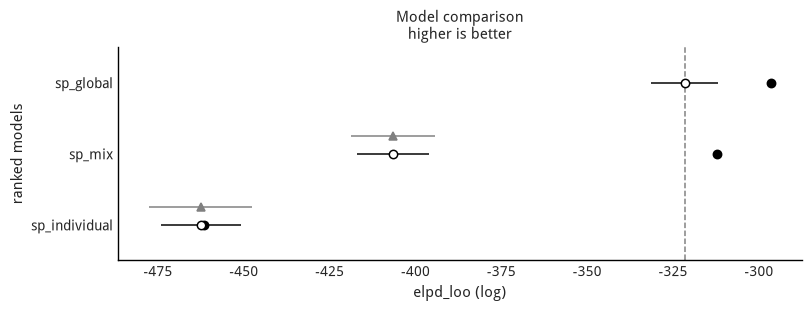

In [34]:
figure, axis = plt.subplots(figsize=(8, 3))
az.plot_compare(
    co2_comparison,
    insample_dev=True,
    plot_ic_diff=True,
    ax=axis,
)
figure.savefig(FIGURE_DIR / "sp_compare.png", bbox_inches="tight")

> **中文版现代化说明**:当前 ArviZ 仍支持 `insample_dev` 与 `plot_ic_diff`。原更新版显式设置
> `insample_dev=False`,却在图注中解释样本内黑点；中文版改为
> `insample_dev=True, plot_ic_diff=True`,使图中同时出现图注所述的样本内点和相对最佳模型的差异
> 误差线。比较所需逐观测对数似然已在所有模型的 `pm.sample(...,
> idata_kwargs={"log_likelihood": True})` 中显式请求。

```{figure} figures/sp_compare.png
:name: fig:sp_compare
:width: 8.00in
当前 `CH5_PROFILE` 运行对 3 个 CO₂ 吸收模型(`sp_global`、`sp_individual`、中心化的
`sp_mix`)所作的 LOO 比较。模型按本次运行的预测准确度从高到低排列。空心圆表示 LOO 值,黑点表示
样本内预测准确度。黑色线段表示 LOO 计算的标准误；以三角形为中心的灰色线段表示各模型 LOO 与
本次最佳模型之差的标准误。`smoke` 图只验证绘图路径,实质结论须使用新的 `release` 输出。
```

(exercises5)=

## 练习

> **中文版现代化说明**:练习所需数据都已放在本章目录的 `data/` 下。5E8 使用
> `data/spectra.csv`(无表头、空白分隔的两列),5M11 使用 `data/babies.csv`,5M15 使用
> `data/space_influenza.csv`,自行车练习继续使用 `data/bikes_hour.csv`。这些说明只明确可执行路径,
> 不提供练习解答。

**5E1.** 样条非常强大,因此有必要知道何时、何地使用它。为巩固理解,请分别解释:

1. 线性回归与样条之间的差异。
2. 哪些情况下你可能更愿意使用线性回归而不是样条。
3. 为什么样条通常优于高次多项式回归。

**5E2.** 重做 {numref}`fig:polynomial_regression`,但这次拟合 0 次和 1 次多项式。它们是否看起来
与其他某类模型相似?提示:可以使用 GitHub 仓库中的代码。

**5E3.** 重做 {numref}`fig:piecewise`,但改变一个或两个节点的位置。节点位置如何影响拟合?代码
可在 GitHub 仓库中找到。

**5E4.** 下面给出几组数据。对每组数据分别拟合 0、1 和 3 次样条。画出拟合,包括数据点与节点
位置。使用 `knots = np.linspace(-0.8, 0.8, 4)`,并描述拟合结果。

1. `x = np.linspace(-1, 1., 200)` 与 `y = np.random.normal(2*x, 0.25)`。
2. `x = np.linspace(-1, 1., 200)` 与 `y = np.random.normal(x**2, 0.25)`。
3. 选择一个你喜欢的函数。

**5E5.** 代码块 [bikes_dmatrix](bikes_dmatrix) 使用了不感知循环的设计矩阵。先画出这个设计矩阵,
再生成并画出循环设计矩阵。两者有什么区别?

**5E6.** 用 Patsy 生成以下设计矩阵:

```python
x = np.linspace(0., 1., 20)
knots = [0.25, 0.5, 0.75]

B0 = dmatrix("bs(x, knots=knots, degree=3, include_intercept=False) +1",
             {"x": x, "knots":knots})
B1 = dmatrix("bs(x, knots=knots, degree=3, include_intercept=True) +1",
             {"x": x, "knots":knots})
B2 = dmatrix("bs(x, knots=knots, degree=3, include_intercept=False) -1",
             {"x": x, "knots":knots})
B3 = dmatrix("bs(x, knots=knots, degree=3, include_intercept=True) -1",
             {"x": x, "knots":knots})
```

1. 每个矩阵的形状是什么?你能解释这些形状为什么取这些值吗?
2. 你能解释参数 `include_intercept=True/False` 与公式中的 `+1/-1` 分别做什么吗?尝试生成类似
   {numref}`fig:splines_basis` 和 {numref}`fig:design_matrices` 的图来帮助回答。

**5E7.** 使用下面列出的选项重新拟合自行车租赁例子。目视比较结果并尝试解释:

1. 先做一个**故意的边界退化实验**:使用代码块 [knot_list](knot_list),但不要删除第一个和最后
   一个位置,也就是把 0 和 23 连同内部位置一起传给 Patsy 的 `knots=`。检查设计矩阵的全零列与秩,
   并解释为什么边界值不是有效的内部节点。随后给出正确版本:只把内部节点传给 `knots=`,并用
   `lower_bound=0, upper_bound=23` 明确指定边界。
2. 使用分位数而不是线性等距来设置**内部**节点；不要把 0% 与 100% 分位数塞进 `knots=`。
3. 用更少的节点重复前两项,同时比较退化写法与正确边界写法的设计矩阵秩和拟合。

**5E8.** 使用 GitHub 仓库中的光谱数据集完成以下任务:

1. 使用节点 `np.quantile(X, np.arange(0.1, 1, 0.02))` 与高斯先验拟合三次样条,参照代码块
   [splines](splines)。
2. 使用节点 `np.quantile(X, np.arange(0.1, 1, 0.02))` 与高斯随机游走先验拟合三次样条,
   参照代码块 [splines_rw](splines_rw)。
3. 使用节点 `np.quantile(X, np.arange(0.1, 1, 0.1))` 与高斯先验拟合三次样条,参照代码块
   [splines](splines)。
4. 目视比较拟合,并使用 LOO 比较。

**5M9.** 重做 {numref}`fig:piecewise`,调用
`plot_piecewise_splines([1.57, 4.71], x_max=12)` 把辅助函数的 `x_max` 参数从默认值 6 扩展到 12。

1. 这个变化如何影响拟合?
2. 它对外推有什么含义?
3. 再增加一个节点,并对代码做必要修改,使拟合真正使用 3 个节点。
4. 改变新增的第三个节点位置,尽可能改善拟合。

**5M10.** 在自行车租赁例子中增加节点数量。拟合会受到什么影响?改变先验宽度,并目视评估它对
拟合的影响。你认为节点数量与先验权重的组合控制了什么?

**5M11.** 使用样条拟合第 [4](chap3) 章中的婴儿回归例子。

**5M12.** 代码块 [bikes_dmatrix](bikes_dmatrix) 使用了不感知循环的设计矩阵。一天中的小时具有
循环结构,所以我们希望使用循环样条。不过这里有一个小问题:原始数据集中的小时范围是 0 到 23,
因此 Patsy 的循环样条会把 0 与 23 当成同一点。我们仍希望进行循环样条回归,请完成以下步骤:

1. 复制 0 点的数据,并把复制项标记为 24 点。
2. 用修改后的数据分别生成循环设计矩阵和非循环设计矩阵。画出结果并比较。
3. 重新拟合自行车样条数据集。
4. 使用图、数值摘要和诊断解释循环样条回归产生了什么影响。

**5M13.** 自行车租赁例子使用高斯似然。当计数较大时,这可以看作合理近似,但仍会带来一些问题,
例如预测出负的租车数量,尤其是夜间观测数量接近 0 时。为解决该问题并改进模型,可以尝试其他似然:

1. 使用泊松(Poisson)似然。提示:可能需要把 $\beta$ 系数限制为正,而且不能像示例中那样标准化
   数据。拟合与书中示例有何不同?它是否更好?在哪种意义上更好?
2. 使用负二项(Negative Binomial)似然。拟合与前两个模型有何不同?你能解释这些差异吗?提示:
   负二项分布可以看作泊松分布的混合模型,这通常有助于建模过度离散数据。
3. 使用 LOO 比较泊松与负二项似然的样条模型。哪个模型的预测表现最好?
4. 你能解释 `p_loo` 的值与 $\hat \kappa$ 的值吗?
5. 使用 LOO-PIT 比较高斯、负二项和泊松模型。

**5M14.** 以代码块 [splines](splines) 中的模型为指导,令 $X\in[0,1]$。尺度参数必须为正,
因此不要把可取负值的 Laplace 随机变量直接作为 `sigma`；改为设
$\lambda_\tau\sim\text{Laplace}(0,1)$ 且 $\tau=\exp(\lambda_\tau)>0$,再令
$\boldsymbol{\beta}\sim\mathcal{N}(0,\tau)$:

1. 从 $\mu$ 的先验中抽样并画出实现。使用不同的节点数量和位置。
2. $\mu(x_i)$ 的先验期望是什么?它如何依赖节点与 $X$?
3. $\mu(x_i)$ 标准差的先验期望是什么?它如何依赖节点与 $X$?
4. 对先验预测分布重复前面的步骤。
5. 使用 $\mathcal{H}\text{C}(1)$ 重复前面的步骤。

**5M15.** 拟合下面的数据。注意响应变量是二元变量,因此需要相应调整似然并使用链接函数。

1. 使用前面章节中的逻辑回归拟合,并与样条模型做目视比较。
2. “太空流感(Space Influenza)”是一种主要影响年轻人与老年人、但不太影响中年人的疾病。幸运的是,
   它完全是虚构的,因此并不真正值得担忧。数据集中记录了接受太空流感检测的人是否患病(1)或健康
   (0),以及他们的年龄。你能只用普通逻辑回归解决这个问题吗?

**5M16.** 除 `hour` 外,自行车数据集还有 `temperature` 等协变量。使用这两个协变量拟合样条。
最简单的方法是为每个协变量分别定义样条/设计矩阵。模型使用负二项似然。

1. 运行诊断以检查采样是否正确,并据此修改模型和/或采样超参数。
2. 租车数量如何依赖一天中的小时?又如何依赖温度?
3. 构建一个只含 `hour` 协变量的模型,与同时包含 `hour` 和 `temperature` 的模型比较。使用 LOO、
   LOO-PIT 和后验预测检验(posterior predictive check, PPC)比较两者。
4. 总结你的全部发现。

[^1]: 详情参见龙格现象(Runge's phenomenon)。泰勒定理也能说明这一点:多项式适合在某个给定点
    附近逼近函数,但未必适合整个定义域。如果仍觉得难以理解,可以观看
    <https://www.youtube.com/watch?v=3d6DsjIBzJ4>。

[^2]: 分段函数(piecewise function)由多个子函数定义,每个子函数适用于定义域中的不同区间。

[^3]: 第 [7](chap6) 章将讨论阶梯函数如何在贝叶斯加性回归树(Bayesian Additive Regression
    Tree, BART)中发挥核心作用。

[^4]: 也可以从数值角度说明这个约束的合理性:它减少了求解时需要确定的系数数量。

[^5]: 与往常一样,恒等函数是一个有效选择。

[^6]: 其他基函数还包括小波或傅里叶级数,第 [6](chap4) 章会看到这些例子。

[^7]: 节点也称为断点(break point),后者可能更容易记,但文献中仍普遍使用 knot 一词。

[^8]: 当次数趋于无穷时,B 样条会覆盖整条实数轴；不仅如此,它还会收敛到高斯函数,见
    <https://www.youtube.com/watch?v=9CS7j5I6aOc>。

[^9]: 如需进一步建立直觉,参见
    <https://pclambert.net/interactivegraphs/spline_continuity/spline_continuity>。

[^10]: 如果感兴趣,可以了解
    <https://en.wikipedia.org/wiki/De_Boor's_algorithm>。

[^11]: <https://patsy.readthedocs.io>

[^12]: <https://archive.ics.uci.edu/ml/datasets/bike+sharing+dataset>

[^13]: 是的,这也称为混合效应模型(mixed-effects model)。你可能还记得第 [4](chap3) 章讨论过的
    相关概念。